![](../../assets/header-logo.png)

## **Advanced Filtering for Object Tracking**

**Automated and Connected Driving Challenges - Research Project - *09/2024***

**Research Topic *8: Advanced Filtering for Object Tracking***

| Author | Mail |
| --- | --- |
| *Manan Vora* | *manan.vora@rwth-aachen.de* |
| *Mayank Mayank* | *mayank.mayank1@rwth-aachen.de* |


**Dependencies and Setup**
The work is based on the pre-existing ACDC project by RWTH ika, which is written in C++. Even through the code cannot be executed directly in the notebook, the ROS nodes can be executed by launching the ACDC docker container. Our implementations based on the ACDC repository can be found on GitHub: https://github.com/mananvora/acdc. To visualize the results, python code snippets are used for which several dependencies are required.

In [1]:
# === INSTALLATION OF PYTHON DEPENDENCIES ==========================

# --- installation of system dependencies via apt ------------------
!echo "jovyan" | sudo -S apt update
!echo "jovyan" | sudo -S apt upgrade

# --- installation via pip -----------------------------------------
import sys

# install packages via pip (version numbers should be included to guarantee reproducibility)
!{sys.executable} -m pip install \
    bagpy~=0.5 \
    matplotlib~=3.4.3 \
    numpy~=1.22.3 \
    opencv-python~=4.6.0.66 \
    tqdm~=4.62.1\
    scipy \
    scikit-learn \
    
    
# === INSTALLATION OF OTHER SYSTEM DEPENDENCIES ====================


# import all packages
import cv2
import matplotlib.pyplot as plt
import numpy as np
import rosbag
import copy 
import scipy
import IPython 

from scipy.stats import gaussian_kde
from copy import deepcopy 
from tqdm.notebook import tqdm
from IPython.display import Video
from IPython.display import display, Image
from sklearn.metrics import mean_squared_error
from matplotlib.animation import FuncAnimation



[sudo] password for manan: Sorry, try again.
[sudo] password for manan: 
sudo: no password was provided
sudo: 1 incorrect password attempt
[sudo] password for manan: Sorry, try again.
[sudo] password for manan: 
sudo: no password was provided
sudo: 1 incorrect password attempt
     |████████████████████████████████| 11.1 MB 6.4 MB/s eta 0:00:01
     |████████████████████████████████| 301 kB 55.9 MB/s eta 0:00:01


#### Abstract

*In the realm of automotive applications, object tracking is a critical component for ensuring safety and enhancing autonomous driving capabilities. In the following report, we present a comprehensive analysis of linear and non-linear filtering techniques employed for object tracking and checking the filter robustness in varying noisy sensor measuremnents. Specifically, we investigate the performance of these filters in the presence of Gaussian and non-Gaussian measurement noise. We initially employ a Constant Velocity (CV) model for the Kalman Filter (KF) which serves as the baseline from the ACDC course and subsequently utilize a Coordinated Turn with Rate and Acceleration (CTRA) model for the Extended Kalman Filter (EKF) and Unscented Kalman Filter (UKF). Through extensive simulations and real-world experiments, we evaluate the tracking accuracy by measuring the Root Mean Square Error (RMSE) against ground truth data which is given by ika/reference topic. Our findings reveal that the UKF outperforms both the EKF and KF, in non-gaussian noise distribution and non-linear motion model providing the most accurate tracking results. However, the EKF offers robust performance in non-linear scenarios and gaussian noise, while the KF, despite its computational efficiency, shows the least accuracy under the tested conditions. This study underscores the importance of selecting appropriate filtering techniques based on the noise characteristics, motion model to capture system dynamics and computational constraints inherent in automotive systems, in complex tracking environments*

### Introduction

In today's world, automated vehicles have emerged as a significant technological advancement that will impact day-to-day life in the near future. To ensure that the Automated Vehicle(AV) behaves safely, environment modeling and prediction are two fundamental steps. For an object-based representation object tracking is an elementary step that involves integration of the environment perception data extracted during sensor data processing. From the environment model, we keep track of the state of different elements in the environment, and the data from the past and present are temporally aligned to associate and fuse them for short-term environment prediction. The object fusion and tracking approaches of choice for this report are the Multi-Instance Kalman Filter (KF), Extended Kalman Filter (EKF), and Unscented Kalman Filter (UKF).  

In the ACDC course, we have seen the implementation of the KF. Good tracking results can be achieved by using the KF. However, it is limited to linear system models and assumptions of Gaussian noise. The results of this approach are questionable for non-linear vehicle motions and non-Gaussian noise models. In this report we will be implementing advanced object fusion and tracking approaches - the Extended Kalman Filter (EKF) and the Unscented Kalman Filter (UKF) which are better equipped for non-linear vehicle motion. Further, we have also implemented non-Gaussian noise to the sensor measurements of the camera and radar for better robustness of the model and evaluated results against the current Multi-Instance Kalman Filter (KF). An exemplary object fusion and tracking of the object environment is presented as follows in the following picture:



![](images/object_fus_n_tracking.png) [[1]]()

The report is structured into the following sections: At first, related work is examined while focusing on implementing different vehicle models to the pre-existing KF model. Building upon the conducted research, the implementation of other filtering methods - EKF and UKF is presented. In order to incorporate the noise addition to the camera and radar sensor measurements, new rosbag files are created based on main.py script provided in the rosbag_noise package and the filtering methods are implemented. In order to verify all implemented changes, changes are made to related parameters to fine-tune the model. Subsequently, in the evaluation section, the results are assessed. Finally, all results are summarized in the conclusion.

### Related Work

Autonomous vehicles (AVs) have gained significant popularity in the automotive industry, prompting extensive research in academia and the industry. AVs are expected to reduce human errors by improving in-road safety, reducing traffic congestion, and mitigating the consequences of accidents. Fundamentally, autonomous vehicles (AVs) are complex systems encompassing multiple critical functions, including environment perception, decision planning, and motion control. To achieve true autonomy, a vehicle must comprehend its driving environment. This entails the ability to localize itself within that environment while simultaneously identifying and tracking both moving and stationary objects. Perception is a fundamental function that is performed first in the overall pipeline of such autonomous systems [[2]](http://users.isr.ist.utl.pt/~mir/pub/kalman.pdf) [[3]](https://cjme.springeropen.com/articles/10.1186/s10033-021-00630-y) [[4]](https://www.researchgate.net/publication/4370048_Comparison_and_evaluation_of_advanced_motion_models_for_vehicle_trackin). 

Over recent decades, car manufacturers have introduced a range of Advanced Driving Assistance Systems (ADAS) functions, such as Electronic Stability Control (ESC), Anti-lock Braking System (ABS), Lane Departure Warning (LDW), and Lane Keep Assist (LKA). These advancements signify a gradual progression toward fully autonomous vehicles. More recent ADAS functionalities, including Collision Avoidance, Automated Highway Driving (Autopilot), and Automated Parking, demand fast and reliable object detection and tracking techniques [[5]](https://etrr.springeropen.com/articles/10.1186/s12544-024-00654-0#citeas). 

A traffic scenario is described by an object state vector for each detected road user, including attributes like type, location, orientation, size, and speed. While human drivers primarily use visual input, some car manufacturers rely on cameras alone, and others incorporate additional sensors. Despite advances in ML-based depth estimation, mono cameras struggle with accurate distance measurement. For safe driving, these state vectors must be highly reliable and involve significant sensor data overlap. Fusion approaches for environment perception are usually divided based on the complexity of the process namely - low-level fusion (LLF), middle-level fusion (MLF), and high-level fusion (HLF). Further, fusion algorithms can be categorized based on the following approaches: (1) Traditional fusion methods that use state estimators like Kalman filters; (2) Machine-Learning methods such as deep neural networks [[6]](https://www.mdpi.com/2227-9717/11/2/501). 

Filtering methods help to estimate the future state of dynamic systems from real-world noisy measurements. They can be divided based on the systems's dynamics into linear and non-linear filters and based on noise characteristics into Gaussian and Non-Gaussian. In integrated navigation systems, the Kalman filter is the primary tool for measurement processing, optimal for linear dynamic and measurement models. Its structure meets the demands of integrated navigation system design. Variants such as the Extended Kalman Filter (EKF), Unscented Kalman Filter (UKF), and Central Difference Kalman Filter (CDKF) are part of the Gauss approximation filters [[7]](https://www.researchgate.net/publication/325410089_Neural_Network_Training_Using_Unscented_and_Extended_Kalman_Filter) and handle non-linear dynamic systems.

#### Motion Models
*In object tracking, the motion model is essential for predicting the future states of a tracked object based on its current state and motion dynamics. In this section, we shall look into the different vehicle motion models that can be used for the implementation of object tracking algorithms. The choice of motion model significantly impacts the accuracy and robustness of the tracking algorithm. This section discusses four commonly used motion models in automotive applications: the Constant Velocity (CV) model, the Constant Acceleration (CA) model, the Coordinated Turn with Rate and Velocity (CTRV) model, and the Coordinated Turn with Rate and Acceleration (CTRA) model.*

1. Constant Velocity (CV) Model:  

![cv_motionmodel](images/cv_motionmodel.png)

*The Constant Velocity (CV) motion model is a fundamental approach in object tracking, particularly favored for its simplicity and computational efficiency. In this model, it is assumed that the tracked object moves with a constant velocity, meaning its speed and direction remain unchanged over time. This assumption simplifies the state transition equations, making the CV model particularly suitable for scenarios where the object's motion is relatively uniform and predictable, such as highway driving. The state vector typically includes the position and velocity components, and the model predicts future states by linearly extrapolating the current state. Despite its simplicity, the CV model can be quite effective in many practical applications, especially when the object's motion does not involve significant acceleration or abrupt changes in direction. However, its performance can degrade in more dynamic environments where the object's motion is non-linear or subject to frequent changes.*

2. Constant Acceleration (CA) Model: 
*The Constant Acceleration (CA) motion model extends the CV model by incorporating acceleration into the state vector. This model assumes that the tracked object moves with a constant acceleration, allowing it to handle scenarios where the object's speed changes over time. The state vector in the CA model typically includes position, velocity, and acceleration components. This model is particularly useful in environments where the object experiences frequent acceleration and deceleration, such as urban driving with stop-and-go traffic. While the CA model provides a more accurate prediction in such scenarios compared to the CV model, it also introduces additional complexity and computational demands.*

![motionmodels](images/motionmodels.png)

This is a visual representation of the four motion models.


3. Coordinated Turn with Rate and Velocity (CTRV) Model: 
*The Coordinated Turn with Rate and Velocity (CTRV) motion model is designed to handle scenarios where the tracked object undergoes coordinated turns while maintaining a constant velocity. This model is particularly suitable for tracking vehicles that follow curved paths, such as those navigating through intersections or roundabouts. The state vector in the CTRV model typically includes position, velocity, heading angle, and turn rate components. By accounting for the turn rate, the CTRV model can accurately predict the object's future states during maneuvers involving changes in direction. However, it assumes that the object's speed remains constant, which may limit its accuracy in scenarios involving significant acceleration or deceleration.*

4. Coordinated Turn with Rate and Acceleration (CTRA) Model: 

![ctra_motionmodel](images/ctra_motionmodel.png)

*The Coordinated Turn with Rate and Acceleration (CTRA) motion model is a more sophisticated approach designed to handle the complexities of real-world object tracking, particularly in automotive applications. Unlike the CV and CTRV models, the CTRA model accounts for both rotational and translational accelerations, making it suitable for scenarios where the tracked object undergoes coordinated turns and varying speeds. The state vector in the CTRA model typically includes position, velocity, heading angle, turn rate, and acceleration components. This allows the model to accurately predict the object's future states even when it is executing maneuvers such as lane changes, turns, or acceleration and deceleration phases. The CTRA model is particularly advantageous in urban driving environments where vehicles frequently change direction and speed. While it offers greater accuracy and robustness compared to simpler models, the CTRA model also demands more computational resources, making it essential to balance performance with real-time processing requirements in automotive systems.*


#### Filtering Methods for Object Tracking
 Filtering methods help to estimate the future state of dynamic systems from real-world noisy measurements. Usually, the accuracy of measuring devices often depends on the accuracy of the device and a model that characterizes the distribution of a measurement error. In integrated navigation systems, the most common tool for processing the measurements is the Kalman filter.
 
 The primary assumption we have for KF is that our position has a Gaussian distribution. This leads to the conclusion that the KF equations are linear. However, due to the fact that the RADAR data provided is in the polar form and not cartesian, the transformation of the coordinates leads to a non-linear equation. Thus the KF equations lose the Gaussian distribution and we cannot use the KF anymore. The KF has numerous modifications like the Extended Kalman Filter(EKF), Unscented Kalman Filter(UKF), Particle Filter(PF), etc. which particularly focus on non-Gaussian position distribution as well as non-Gaussian noise distributions. [[8]](https://intapi.sciendo.com/pdf/10.2478/rgg-2014-0008) In this report we shall be looking into the implementation of the first two non-Gaussian filtering methods that have been mentioned along with the the KF. 

<img src="images/kf_ekf_ukf.jpg" width="300"/>

[[7]](https://www.researchgate.net/publication/325410089_Neural_Network_Training_Using_Unscented_and_Extended_Kalman_Filter/figures?lo=1)
 
##### 1. Kalman Filter (KF):
Kalman Filter takes in linear dynamic systems and assumes that the measurement noise is Gaussian. It is the most popular filtering algorithm and has applications in navigation, tracking, and control systems. It has two steps - Prediction and Update.

In the prediction step, based on the state transition model (following the same symbols and convention used in ACDC), the state is estimated at a future time step based on the current state and associated uncertainty. In the update step, the measurement is used to refine the predicted state and reduce uncertainty based on Kalman Gain.

Since KF uses linear systems, we have used the Constant Velocity motion model for state estimation. The state matrix __x__ is the estimated object state vector where \( (x, y, z) \) is the bounding box center position, \( (v<sub>x</sub>, v<sub>y</sub>, a<sub>x</sub>, a<sub>y</sub>) \) are the velocities and accelerations in \( x \) and \( y \) direction, and \( (l, w, h) \) is the bounding box length, width, and height.

$$
\mathbf{x} = \begin{bmatrix} x \\ y \\ z \\ v_x \\ v_y \\ a_x \\ a_y \\ l \\ w \\ h \\ \end{bmatrix} = 
\begin{bmatrix} \text{Position x} \\ \text{Position y} \\ \text{Position z} \\ \text{Velocity x component} \\ \text{Velocity y component} \\ \text{Acceleration x component} \\ \text{Acceleration y component} \\ \text{Length} \\ \text{Width} \\ \text{Height} \\ \end{bmatrix}
$$

Assuming constant (v<sub>x</sub>) and (v<sub>y</sub>), the next state can be rewritten as follows:

$$
\mathbf{x}_{k+1} = \mathbf{x}_{k} + \int_0^{\Delta t} \begin{bmatrix}
v_x \\ v_y \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ \end{bmatrix} \, dt
$$
The indices with 'G' subscript represent results from a global fusion algorithm / global environment model and with 'S' from a sensor. Thus, \( \hat{x}_S \) is the measured state vector, and \( \hat{x}_G \) is the global/fused state vector.

The indices with 'G' subscript represent results from a global fusion algorithm / global environment model and with 'S' from a sensor. Thus, $\widehat{x}_S$ is the measured state vector, and $\widehat{x}_G$ is the global/fused state vector.

**Prediction Step:**
$$
\widehat{x}_{G,k|k-1} = F \widehat{x}_{G,k-1|k-1}
$$

$$ 
\mathbf{F} = \begin{bmatrix}
1 & 0 & 0 & \Delta t & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & \Delta t & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
\end{bmatrix}
$$
where $\mathbf{F}$ is the Constant Velocity motion model matrix and $\Delta t$ is the prediction gap between the currently measured object and the already existing global object.

$$
P_{G,k|k-1} = F P_{G,k-1|k-1} F^T + Q
$$
where $\mathbf{P}$ is the uncertainty of the object state described by its error covariance matrix, and $\mathbf{Q}$ is the motion noise matrix, also called process noise.

**Update Step:**
$$
z_k = C \widehat{x}_{S,k|k}
$$
$$
\mathbf{C} = \begin{bmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
\end{bmatrix}
$$
where $\mathbf{C}$ is the measurement matrix, and here the sensor provides measurements for all state variables except $z$, $a_x$, $a_y$, and $h$.

$$
R = C P_{S,k-1|k-1} C^T
$$
where $\mathbf{R}$ is the measurement error covariance.

$$
\tilde{y} = z_k - C \widehat{x}_{G,k|k-1}
$$
where $\mathbf{\tilde{y}}$ is the innovation directing from "G" to "S".

$$
S = R + C P_{G,k|k-1} C^T
$$
where $\mathbf{S}$ is the innovation error covariance.

$$
K = P_{G,k|k-1} C^T (S)^{-1}
$$
where $\mathbf{K}$ is the Kalman gain and measures the weighing factor in a scale of 0 (staying at the global object) to 1 (staying at measurement).

$$
\widehat{x}_{G,k|k} = \widehat{x}_{G,k|k-1} + K y_k
$$
where $\widehat{x}_{G,k|k}$ is the fused state estimate, which goes along the direction of innovation according to the Kalman Gain.

$$
P_{G,k|k} = (I - K C) P_{G,k|k-1}
$$
where $\mathbf{P_{G,k|k}}$ is the fused state uncertainty, which is required for the next time step in the prediction step.

##### 2. Extended Kalman Filter (EKF): 

The EKF advances the KF to handle non-linear dynamic systems by carrying out non-linear transformation by its first-order Taylor expansion using the Jacobian matrix. The linearization can introduce errors and lead to suboptimal performance if it leads to poor representation of non-linear dynamic systems. 

$$
\mathbf{x} = \begin{bmatrix}
x \\
y \\
z \\
v \\
a \\
\psi \\
\dot{\psi} \\
l \\
w \\
h \\
\end{bmatrix} = \begin{bmatrix}
\text{Position x} \\
\text{Position y} \\
\text{Position z} \\
\text{Absolute Velocity} \\
\text{Absolute Acceleration} \\
\text{Heading Angle} \\
\text{Yaw Rate} \\
\text{Length} \\
\text{Width} \\
\text{Height} \\
\end{bmatrix}
$$

where \(x\) and \(y\) are the 2D coordinates of an object, $\psi$ is its yaw (orientation, measured counterclockwise from the x-axis), \(v\) is the linear velocity in the direction in which the object is facing, $\dot{\psi}$ is angular velocity (also known as the turn rate), and \(a\) is the linear acceleration along the direction of orientation.



Assuming constant $\dot{\psi}$ and \(a\), the next state can be rewritten as follows:
$$
\mathbf{x}_{k+1} = \mathbf{x}_{k} + \int_0^{\Delta t} \begin{bmatrix}
\left( v + \int_0^{\Delta t} a \, dt \right) \cos \left( \psi + \int_0^{\Delta t} \dot{\psi} \, dt \right) \\
\left( v + \int_0^{\Delta t} a \, dt \right) \sin \left( \psi + \int_0^{\Delta t} \dot{\psi} \, dt \right) \\
0 \\
a \\
0 \\
\dot{\psi} \\
0 \\
0 \\
0 \\
0 \\
\end{bmatrix} \, dt
$$

$$
\mathbf{x}_{k+1} = \begin{bmatrix}
x_k + \frac{1}{\dot{\psi}_k^2} \left( \left( v_k \dot{\psi}_k + a_k \dot{\psi}_k \Delta t \right) \sin(\psi_k + \dot{\psi}_k \Delta t) \right. \\
\quad + a_k \cos(\psi_k + \dot{\psi}_k \Delta t) - v_k \dot{\psi}_k \sin(\psi_k) \\
\quad - a_k \cos(\psi_k) \\
y_k + \frac{1}{\dot{\psi}_k^2} \left( \left( -v_k \dot{\psi}_k - a_k \dot{\psi}_k \Delta t \right) \cos(\psi_k + \dot{\psi}_k \Delta t) \right. \\
\quad + a_k \sin(\psi_k + \dot{\psi}_k \Delta t) + v_k \dot{\psi}_k \cos(\psi_k) \\
\quad - a_k \sin(\psi_k) \\
z_k \\
v_k + a_k \Delta t \\
a_k \\
\psi_k + \dot{\psi}_k \Delta t \\
\dot{\psi}_k \\
l_k \\
w_k \\
h_k \\
\end{bmatrix}
$$  


The Jacobian matrix $J$ of the state transition model is given by:
$$
\mathbf{J} = \begin{bmatrix}
\frac{\partial x_{k+1}}{\partial x_k} & \frac{\partial x_{k+1}}{\partial y_k} & \frac{\partial x_{k+1}}{\partial z_k} & \frac{\partial x_{k+1}}{\partial v_k} & \dots & \frac{\partial x_{k+1}}{\partial h_k} \\
\frac{\partial y_{k+1}}{\partial x_k} & \frac{\partial y_{k+1}}{\partial y_k} & \frac{\partial y_{k+1}}{\partial z_k} & \frac{\partial y_{k+1}}{\partial v_k} & \dots & \frac{\partial y_{k+1}}{\partial h_k} \\
\frac{\partial z_{k+1}}{\partial x_k} & \frac{\partial z_{k+1}}{\partial y_k} & \frac{\partial z_{k+1}}{\partial z_k} & \frac{\partial z_{k+1}}{\partial v_k} & \dots & \frac{\partial z_{k+1}}{\partial h_k} \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\
\frac{\partial h_{10}}{\partial x_k} & \frac{\partial h_{10}}{\partial y_k} & \frac{\partial h_{10}}{\partial z_k} & \frac{\partial h_{10}}{\partial v_k} & \dots & \frac{\partial h_{10}}{\partial h_k} \\
\end{bmatrix}
$$

Jacobian Matrix

$$
\frac{\partial x_{k+1}}{\partial x_k} = 1
$$

Partial Derivative with Respect to v<sub>k</sub>

$$
\begin{aligned}
\frac{\partial x_{k+1}}{\partial v_k} = & \frac{1}{\dot{\psi}_k^2} \left( \dot{\psi}_k \sin(\psi_k + \dot{\psi}_k \Delta t) - \dot{\psi}_k \sin(\psi_k) \right) \\
= & \frac{1}{\dot{\psi}_k} \left( \sin(\psi_k + \dot{\psi}_k \Delta t) - \sin(\psi_k) \right)
\end{aligned}
$$

Partial Derivative with Respect to a<sub>k</sub>

$$
\begin{aligned}
\frac{\partial x_{k+1}}{\partial a_k} = & \frac{1}{\dot{\psi}_k^2} \left( \dot{\psi}_k \Delta t \sin(\psi_k + \dot{\psi}_k \Delta t) + \cos(\psi_k + \dot{\psi}_k \Delta t) - \cos(\psi_k) \right)
\end{aligned}
$$

Partial Derivative with Respect to $\psi_k$

$$
\begin{aligned}
\frac{\partial x_{k+1}}{\partial \psi_k} = & \frac{1}{\dot{\psi}_k^2} \left( (v_k \dot{\psi}_k + a_k \dot{\psi}_k \Delta t) \cos(\psi_k + \dot{\psi}_k \Delta t) \right. \\
& \quad - a_k \sin(\psi_k + \dot{\psi}_k \Delta t) - v_k \cos(\psi_k) \\
& \quad + a_k \sin(\psi_k) \left. \right)
\end{aligned}
$$

Partial Derivative with Respect to $\dot{\psi}_k$

$$
\begin{aligned}
\frac{\partial x_{k+1}}{\partial \dot{\psi}_k} = & \frac{1}{\dot{\psi}_k^3} \left[ 
(v_k + a_k \Delta t) \sin(\psi_k + \dot{\psi}_k \Delta t) \right. \\
& \left. + (v_k \dot{\psi}_k + a_k \dot{\psi}_k \Delta t) \cos(\psi_k + \dot{\psi}_k \Delta t) \Delta t \right. \\
& \left. - a_k \sin(\psi_k + \dot{\psi}_k \Delta t) \Delta t \right] \\
& - \frac{2}{\dot{\psi}_k^3} \left[ (v_k \dot{\psi}_k + a_k \dot{\psi}_k \Delta t) \sin(\psi_k + \dot{\psi}_k \Delta t) \right. \\
& \left. + a_k \cos(\psi_k + \dot{\psi}_k \Delta t) - v_k \dot{\psi}_k \sin(\psi_k) - a_k \cos(\psi_k) \right]
\end{aligned}
$$

The Extended Kalman Filter equations are similar to the Kalman Filter but involve linearizing the system dynamics and measurement functions around the current state estimate.

Prediction Step:

$$
\hat{x}_{G,k|k-1} = f(\hat{x}_{G,k-1|k-1})
$$

where **$f$** is the non-linear state equation from the CTRA motion model.

$$
P_{G,k|k-1} = J_f P_{G,k-1|k-1} J_f^T + Q_k
$$

where **$J_f$** is the Jacobian of the state vector.

Update Step:

$$
z_k = C(\hat{x}_{S,k|k})
$$

$$
R = J_c P_{G,k|k-1} J_c^T
$$

$$
\tilde{y} = z_k - C(\hat{x}_{G,k|k-1})
$$

$$
S = R + J_c P_{G,k|k-1} J_c^T
$$

$$
K = P_{G,k|k-1} J_c^T (S)^{-1}
$$

$$
\hat{x}_{G,k|k} = \hat{x}_{G,k|k-1} + K y_k
$$

$$
P_{G,k|k} = (I - K_k J_c) P_{G,k|k-1}
$$
Here, the symbols have the same meaning as declared in the KF like the error covarinaces R, S and Kalman gain, K.

##### 3. Unscented Kalman Filter (UKF): 

Because the Extended Kalman Filter (EKF) uses only the first-order derivative in its linearization process and neglects higher-order terms, errors accumulate in the state and covariance estimations. To address this limitation, the Unscented Kalman Filter (UKF) was introduced by Wan et al. in 2000. The UKF is a derivative-free alternative to the EKF that employs a deterministic sampling approach. 

In the UKF process, the state Gaussian distribution is represented using a minimal set of carefully chosen sample points, known as sigma points. Here, $ \chi_{k-1} \ $ is the sigma-point matrix which includes $ L $ sigma-point vectors (equal to the dimensions of state vector), and $ \lambda $ is a design parameter that determines the spread of the generated sigma points.The parameters for a are varied from 10e-3 to 1, beta from 0 to 2 and kappa is kept 0 as from the original Unscented Kalman filter paper available at  [[10]](https://groups.seas.harvard.edu/courses/cs281/papers/unscented.pdf).

Sigma Points: 

$$
\chi_{k-1} = \left[\hat{x}_{k-1}, \hat{x}_{k-1} + \sqrt{(L+\lambda)P_{k-1}}, \hat{x}_{k-1} - \right.  \left. \sqrt{(L+\lambda)P_{k-1}}\right] 
$$

State Prediction: 


$$ \chi_{k|k-1}^i = f(\chi_{k-1}^i), \quad i = 0, \ldots, 2L  $$

$$ W_{m}^0 = \frac{\lambda}{L + \lambda} $$

$$ W_{c}^0 = \frac{\lambda}{L + \lambda} + (1 - a^2 + \beta) $$

$$ W_{m}^i = W_{c}^i = \frac{1}{2(L + \lambda)} $$

$$ \lambda = a^2 (L + \kappa) - L $$

$$ \hat{x}_{k|k-1} = \sum_{i=0}^{2L} W_m^i \chi_{k|k-1}^i $$

$$ P_{k|k-1} = \sum_{i=0}^{2L} W_c^i \left(\chi_{k|k-1}^i - \hat{x}_{k|k-1}\right) \left(\chi_{k|k-1}^i - \hat{x}_{k|k-1}\right)^T + Q_k $$

Update Step:
$$ \chi_{k|k-1} = \left[\hat{x}_{k|k-1}, \hat{x}_{k|k-1} + \sqrt{(L+\lambda)P_{k|k-1}}, \hat{x}_{k|k-1} - \sqrt{(L+\lambda)P_{k|k-1}}\right] $$

Measurement Prediction: 

$$ \gamma_{k|k-1}^i = h(\chi_{k|k-1}^i), \quad i = 0, \ldots, 2L $$

$$ \hat{z}_{k|k-1} = \sum_{i=0}^{2L} W_m^i \gamma_{k|k-1}^i $$

$$ P_{zz} = \sum_{i=0}^{2L} W_c^i \left(\gamma_{k|k-1}^i - \hat{z}_{k|k-1}\right) \left(\gamma_{k|k-1}^i - \hat{z}_{k|k-1}\right)^T + R_k $$ 

$$ P_{xz} = \sum_{i=0}^{2L} W_c^i \left(\chi_{k|k-1}^i - \hat{x}_{k|k-1}\right) \left(\gamma_{k|k-1}^i - \hat{z}_{k|k-1}\right)^T $$

Update: 
$$ K_k = P_{xz} P_{zz}^{-1} $$
$$ \hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k (z_k - \hat{z}_{k|k-1}) $$
$$ P_{k|k} = P_{k|k-1} - K_k P_{zz} K_k^T $$

### Noise Distribution

In object tracking, the accuracy and robustness of the filtering algorithm are heavily influenced by the noise characteristics of the system. Traditional Kalman filters assume Gaussian noise, which is characterized by a normal distribution with a known mean and variance. However, this assumption does not hold true in many real-world applications, and the noise encountered may exhibit non-Gaussian properties. The current section thus explores the importance of noise distribution, the types of non-Gaussian noise, and their impact on the performance of tracking algorithms.

The distribution of noise is a critical factor in the reliability of tracking systems. Deviation from Gaussian assumption affects the performance of the KF leading to sub-optimal outcomes. This is primarily because; the KF, which is optimized for Gaussian noise, does not adequately account for the true characteristics of non-Gaussian noise. Such deviations can introduce biases, diminish accuracy, and reduce the system's robustness to outliers. Consequently, addressing non-Gaussian noise is trivial for enhancing the performances of the EKF and UKF. As a result, it is essential to consider alternative noise distributions that can handle non-Gaussian motion models. By doing so, we can improve the system's ability to accurately track objects, even in the presence of complex and unpredictable noise. In the subsequent subsections, we will look at the different types of noise distribution models used to evaluate and compare the filtering models for an extensive analytic comparison.

#### 1. Gaussian Noise Distribution

Gaussian noise was introduced to the object-tracking system to simulate sensor measurement uncertainty. Gaussian noise is typically defined as a random variable or vector that follows a Gaussian (normal) distribution. In mathematical terms, it can be expressed as:

$$ w \sim \mathcal{N}(\mu, \sigma^2) $$

where $ \sigma $ is the standard deviation and $\mu$ the mean of the function. This noise is then incorporated into the state vector to simulate measurement uncertainties, consistent with the multivariate Gaussian distribution when extended to multiple dimensions and components. For each component, the noise was generated using a normal distribution, where the mean $\mu$ was set to 0, reflecting no systematic bias, and the standard deviation $ \sigma $ was selected based on the expected variability in the sensor measurements. The covariance matrix **$P$** was subsequently adjusted to reflect the variances $ \sigma^2 $ associated with this noise, ensuring that the filter accurately accounted for the added uncertainty. 

#### 2. Laplace Noise Distribution

he Laplace noise distribution, also known as the double-exponential distribution, is another non-Gaussian distribution that is characterized by its heavier tails compared to Gaussian noise, making it useful for modeling scenarios where outliers or large deviations from the mean are more likely. This is a more robust noise model that can handle larger deviations from the mean hence making it more realistic in practical scenarios. The probability density function (PDF) of the Laplace distribution is given by:

$$ f(w|\mu, b) = \frac{1}{2b} \exp\left(-\frac{|w - \mu|}{b}\right) $$

where $w$ is the noise variable, $\mu$ is the location parameter (mean), \$b$ is the scale parameter, which controls the spread or variance of the distribution. The mean of the Laplace distribution is $\mu$, and the variance $\sigma^2$ is given by:

$$ \sigma^2 = 2b^2 $$

The noise generation uses the inverse transform sampling method, transforming uniform random variables to follow the Laplace distribution. The Laplace distribution noise can be generated as:

$$ w = \mu - b \, \text{sign}(U) \, \ln(1 - 2|U|) $$

The covariance matrix is adjusted accordingly since the Laplace noise has a variance different from the Gaussian noise. The introduction of Laplace noise affects the predicted state as well as the updated covariance matrix.

#### 3. Cauchy Noise Distribution

The Cauchy noise distribution is a type of non-Gaussian noise characterized by its heavy tails, where it is more likely to produce extreme values than a Gaussian distribution. This property of the Cauchy distribution makes it suitable for scenarios where large deviations or outliers are more likely. However, one of the major challenges of applying Cauchy noise distribution lies in the fact that it does not have a finite mean or variance. The Cauchy distribution is described by the following probability density function (PDF):

$$ f(x; x_0, \gamma) = \frac{1}{\pi \gamma \left[1 + \left(\frac{x - x_0}{\gamma}\right)^2\right]} $$

where $x_0$ is the location parameter (the median of the distribution) and  $\gamma$ is the scale parameter (which defines the half-width at half-maximum).

Introducing Cauchy noise in EKF and UKF requires careful handling because the linearization steps rely on the assumption of finite variance.While the Cauchy noise distribution is a non-Gaussian noise model that theoretically challenges the assumptions of KF, EKF, and UKF, it can still be applied under certain conditions where the system must be robust to outliers. The application of Cauchy noise needs careful adjustment of the covariance matrix in both EKF and UKF, using heuristic methods to approximate the effects of the noise. This approach ensures that the filters can accommodate the heavy-tailed nature of Cauchy noise, providing a more realistic model of systems where extreme deviations are possible.

#### 4. Log Normal Noise Distribution

The Log Normal noise distribution is a continuous probability distribution whose logarithm is normally distributed. In contrast to the Gaussian distribution, the log-normal distribution is skewed. This noise distribution is commonly used to model data that cannot take negative values and is suitable for scenarios where errors or deviations grow exponentially. A key characteristic of the log-normal distribution is that it produces a long right tail, meaning that large values are possible but rare.

The log-normal distribution is described by the following probability density function (PDF):

$$ f(x; \mu, \sigma) = \frac{1}{x \sigma \sqrt{2\pi}} \exp\left( -\frac{(\ln x - \mu)^2}{2\sigma^2} \right) \quad \text{for} \quad x > 0 $$

where $\mu$ is the mean, $\sigma$ is the standard deviation of the normal distribution. 

When using log-normal noise in Extended Kalman Filter (EKF) and Unscented Kalman Filter (UKF), careful adjustments need to be made to account for the non-Gaussian characteristics. Since the log-normal distribution produces skewed values with a larger occurrence of high outliers, this noise model is particularly useful for modeling systems where growth or errors are multiplicative, such as in financial data or biological systems. To integrate log-normal noise, special attention must be given to maintaining the stability of the filter in scenarios where high deviations are likely.




The following is a representation of the noises. This is the visual rerpresentation of the noise that has been added to bag files for object tracking. Here we have shown the plot of noise distributions using a simple python script. 

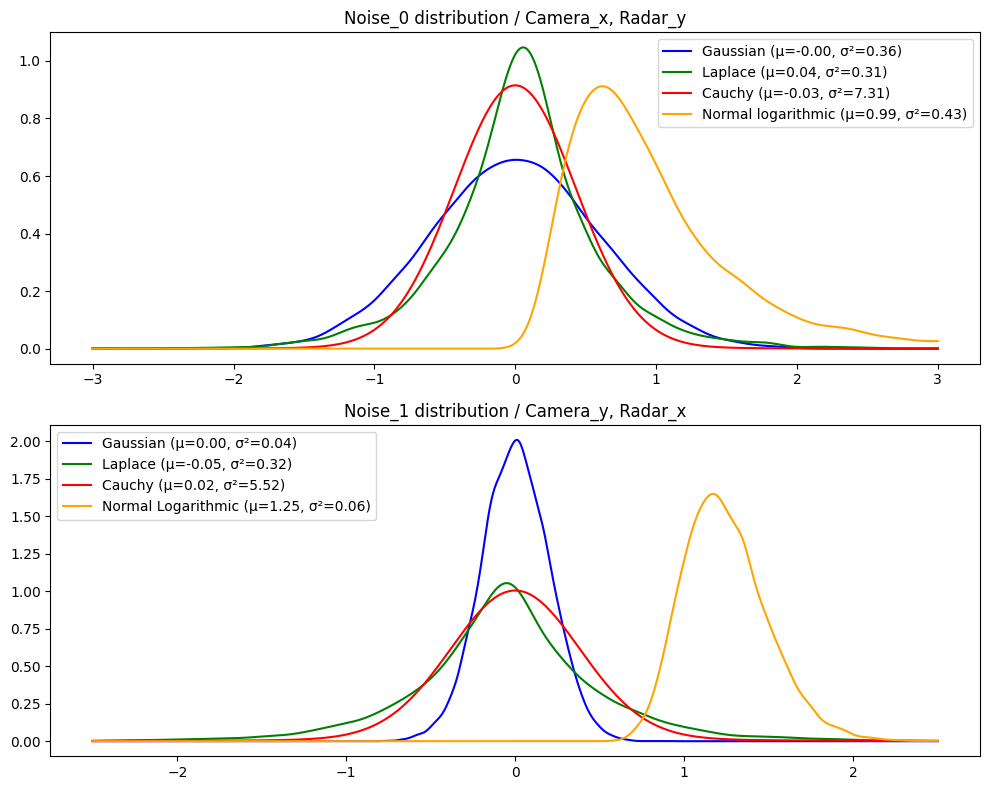

In [2]:
# Set random seed for reproducibility
np.random.seed(42)
n_samples = 10000

# Generate noise_0 and noise_1 for different distributions
# Gaussian
noise_0_gaussian = np.random.normal(0, 0.6, n_samples)
noise_1_gaussian = np.random.normal(0, 0.2, n_samples)

# Laplace
noise_0_laplace = np.random.laplace(0.05, 0.4, n_samples)
noise_1_laplace = np.random.laplace(-0.05, 0.4, n_samples)

# Cauchy
noise_0_cauchy = np.random.standard_cauchy(n_samples) * 0.01
noise_1_cauchy = np.random.standard_cauchy(n_samples) * 0.03

# Lognormvariate
noise_0_lognormal = np.random.lognormal(-0.2, 0.6, n_samples)
noise_1_lognormal = np.random.lognormal(0.2, 0.2, n_samples)

# Create an array of values to evaluate the density
x_vals_0 = np.linspace(-3, 3, 1000)
x_vals_1 = np.linspace(-2.5, 2.5, 1000)

# calculate mean and variance
def mean_var(data):
    return np.mean(data), np.var(data)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# KDE for noise_0
kde_0_gaussian = gaussian_kde(noise_0_gaussian)
kde_0_laplace = gaussian_kde(noise_0_laplace)
kde_0_cauchy = gaussian_kde(noise_0_cauchy)
kde_0_lognormal = gaussian_kde(noise_0_lognormal)

mu_0_gaussian, var_0_gaussian = mean_var(noise_0_gaussian)
mu_0_laplace, var_0_laplace = mean_var(noise_0_laplace)
mu_0_cauchy, var_0_cauchy = mean_var(noise_0_cauchy)
mu_0_lognormal, var_0_lognormal = mean_var(noise_0_lognormal)

# Subplot 1:
ax1.plot(x_vals_0, kde_0_gaussian(x_vals_0), label=f'Gaussian (μ={mu_0_gaussian:.2f}, σ²={var_0_gaussian:.2f})', color='blue')
ax1.plot(x_vals_0, kde_0_laplace(x_vals_0), label=f'Laplace (μ={mu_0_laplace:.2f}, σ²={var_0_laplace:.2f})', color='green')
ax1.plot(x_vals_0, kde_0_cauchy(x_vals_0), label=f'Cauchy (μ={mu_0_cauchy:.2f}, σ²={var_0_cauchy:.2f})', color='red')
ax1.plot(x_vals_0, kde_0_lognormal(x_vals_0), label=f'Normal logarithmic (μ={mu_0_lognormal:.2f}, σ²={var_0_lognormal:.2f})', color='orange')
ax1.set_title('Noise_0 distribution / Camera_x, Radar_y')
ax1.legend()

kde_1_gaussian = gaussian_kde(noise_1_gaussian)
kde_1_laplace = gaussian_kde(noise_1_laplace)
kde_1_cauchy = gaussian_kde(noise_1_cauchy)
kde_1_lognormal = gaussian_kde(noise_1_lognormal)

mu_1_gaussian, var_1_gaussian = mean_var(noise_1_gaussian)
mu_1_laplace, var_1_laplace = mean_var(noise_1_laplace)
mu_1_cauchy, var_1_cauchy = mean_var(noise_1_cauchy)
mu_1_lognormal, var_1_lognormal = mean_var(noise_1_lognormal)

# Subplot 2:
ax2.plot(x_vals_1, kde_1_gaussian(x_vals_1), label=f'Gaussian (μ={mu_1_gaussian:.2f}, σ²={var_1_gaussian:.2f})', color='blue')
ax2.plot(x_vals_1, kde_1_laplace(x_vals_1), label=f'Laplace (μ={mu_1_laplace:.2f}, σ²={var_1_laplace:.2f})', color='green')
ax2.plot(x_vals_1, kde_1_cauchy(x_vals_1), label=f'Cauchy (μ={mu_1_cauchy:.2f}, σ²={var_1_cauchy:.2f})', color='red')
ax2.plot(x_vals_1, kde_1_lognormal(x_vals_1), label=f'Normal Logarithmic (μ={mu_1_lognormal:.2f}, σ²={var_1_lognormal:.2f})', color='orange')
ax2.set_title('Noise_1 distribution / Camera_y, Radar_x')
ax2.legend()


plt.tight_layout()
plt.show()

## Methodology

In the following paragraph, the methodology and implementation of filtering techniques for improving robustness towards non-Gaussian noise is described in detail. First, the addition of noise to camera and sensor measurements is discussed to generate different non-gaussian noisy bag files. Afterwards, the motion model pre-processing of rosbags (CV - for KF and CTRA - EKF and UKF) is discussed followed by the implementation of the filtering techniques on the ROS nodes.

#### Pre-Processing Bag Files
In this section, at first, the motivation to pre-process bag files is discussed. Afterward, the approach of modifying the bag files for suitable vehicle models is described in detail, including the introduction and calculation of yawrate of the vehicle to the state vector. 

The bag files provided in the [ACDC course](https://rwth-aachen.sciebo.de/s/zRiQvCykdDBHNpF) are:
1. *acdc_fusion_guidance.bag* - contains ground-truth object lists
2. *acdc_fusion_guidance_noise.bag* - contains Gaussian noised object lists as used in the ACDC course.

However for simplicity and reduce the number of steps, the bag files are pre-processed after noise addition to the bagfiles. 

### Noise Generation and Addition

In this context, noise is applied to sensor measurements by modifying the *fMean* (state vector) values within the sensor data. Specifically, noise is added to the position measurements *posX* and *posY* to simulate real-world sensor inaccuracies. Noise is added to the *IkaObjectList* message from the */reference/ikaObjectList* topic. This topic contains the IkaObjectList messages from which the noise is applied. For each original message to */sensors/reference/ikaObjectList* noise is added to create new *IkaObjectList* messages for the camera and radar sensors and writes them to */sensors/camera_front/ikaObjectList* and */sensors/radar_front/ikaObjectList* respectively. As previously mentioned, 4 different noises are applied to the **acdc_fusion_guidance.bag** file.


1. **Gaussian Noise**: A sample script for noise addition was already provided in the ACDC course in the **main.py** file. Noise is added to the state vector, specifically to the x and y positions of the object detected. For the camera sensor, noise added has a *mean =0* and *standard deviation = 0.6(in x), 0.2(in y)*. Similarly, for the radar sensor, noise added has a *mean =0* and *standard deviation = 0.2(in x), 0.6(in y)* The following code block cell is an excerpt from the same script.

```py 
# //source: /acdc/catkin_workspace/src/dependencies/rosbag_noise/scripts/main.py

    for reference_object in object_list.objects:
        obj = deepcopy(reference_object)
        if mode == 'camera':
            obj.fMean = list(obj.fMean)
            obj.fMean[0] += random.gauss(0, 0.6)
            obj.fMean[1] += random.gauss(0, 0.2)

        elif mode == 'radar':
            obj.fMean = list(obj.fMean)
            obj.fMean[0] += random.gauss(0, 0.2)
            obj.fMean[1] += random.gauss(0, 0.6)
```

2. **Laplace Noise**: Similar to the Gaussian noise that was added a new script is generate with the aim to add Laplace noise. Noise is added to the state vector, specifically to the x and y positions of the object detected. For the noise generation, the location and the scale parameters in the *np.random.laplace()*  function are set suitably to generate noise in the camera and radar sensor measurements. The following code block cell is an excerpt from the same script.

```py 
# //source: /acdc/catkin_workspace/src/dependencies/rosbag_noise/scripts/laplace.py

    for reference_object in object_list.objects:
        obj = deepcopy(reference_object)
        if mode == 'camera':
            obj.fMean = list(obj.fMean)
            obj.fMean[0] += np.random.laplace(0.05, 0.4)
            obj.fMean[1] += np.random.laplace(-0.05, 0.4)

        elif mode == 'radar':
            obj.fMean = list(obj.fMean)
            obj.fMean[0] += np.random.laplace(-0.05, 0.4)
            obj.fMean[1] += np.random.laplace(0.05, 0.4)
```

3. **Cauchy Noise**: Similar to the Laplace noise that was added to */fusion/ikaObjectList* a new script is generated with the aim to add Cauchy noise distribution. Noise is added to the state vector *(fMean)*, specifically to the x and y positions of the object detected. For the noise generation, the location and the scale parameters in the *np.random.cauchy ()* function are set suitably to generate noises in the camera and radar sensor measurements. The following code block cell is an excerpt from the same script.

```py
# //source: /acdc/catkin_workspace/src/dependencies/rosbag_noise/scripts/cauchy.py

    for reference_object in object_list.objects:
        obj = deepcopy(reference_object)
        if mode == 'camera':
            obj.fMean = list(obj.fMean)
            obj.fMean[0] += np.random.standard_cauchy()*0.01
            obj.fMean[1] += np.random.standard_cauchy()*0.03

                    elif mode == 'radar':
            obj.fMean = list(obj.fMean)
            obj.fMean[0] += np.random.standard_cauchy()*0.03
            obj.fMean[1] += np.random.standard_cauchy()*0.01
```

4. **Normal Logarithmic Noise**:  Similar to the Laplace and Cauchy noise that was added to */fusion/ikaObjectList* a new script is generated with the aim to add normal logarathmic noise distribution. Noise is added to the state vector *(fMean)*, specifically to the x and y positions of the object detected. For the noise generation, the location and the scale parameters in the *np.random.lognormal()*  function are set suitably to generate noises in the camera and radar sensor measurements. The following code block cell is an excerpt from the same script.

```py
# //source: /acdc/catkin_workspace/src/dependencies/rosbag_noise/scripts/lognormal.py

    for reference_object in object_list.objects:
        obj = deepcopy(reference_object)
        if mode == 'camera':
            obj.fMean = list(obj.fMean)
            obj.fMean[0] += random.lognormal(-0.2, 0.6)
            obj.fMean[1] += random.lognormal(0.2, 0.2)

        elif mode == 'radar':
            obj.fMean = list(obj.fMean)
            obj.fMean[0] += random.lognormal(0.2, 0.2)
            obj.fMean[1] += random.lognormal(-0.2, 0.6)
```

```txt
// source: acdc_fusion_guidance_noise.bag 
// Example message for one measured object

header: 
  seq: 26845
  stamp: 
    secs: 12
    nsecs: 401000000
  frame_id: "base_link"
IdSource: 16
objects: 
  - 
    header: 
      seq: 0
      stamp: 
        secs: 0
        nsecs:         0
      frame_id: ''
    IdMotionModel: 2
    fMean: [56.337890625, 4.2293620109558105, 0.19427743554115295, 10.755064964294434, -0.44741731882095337, -1.4652472734451294, -0.21698182821273804, 4.28000020980835, 1.8200000524520874, 1.2799999713897705, -0.044611189514398575]
    fCovariance: [0.36000001430511475, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.03999999910593033, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.009999999776482582, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.009999999776482582, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.009999999776482582, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.009999999776482582, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.009999999776482582, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.009999999776482582, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.009999999776482582, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.009999999776482582, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.009999999776482582]
    fRelVelX: -2.047548532485962
    fRelVelY: -0.46780356764793396
    fRelAccX: -2.086247205734253
    fRelAccY: -0.6884417533874512
    RefLocation: 0
    fRefX: 0.0
    fRefY: 0.0
    IdInternal: 9216
    IdLane: 0
    IdType: 4
    fClassProbability: []
    fExistenceProbability: 1.0
    IdExternal: 16
    measHist: 
      - 
        IdSensor: 16
        IdObjectWithinSensor: 9216
        measuredStamp: 
          secs: 12
          nsecs: 401000000
    birthStamp: 
      secs: 0
      nsecs:         0
    bObjectValid: True
    bObjectNew: False
    bObjectMeasured: True
```


```txt
//source: /acdc/catkin_workspace/src/dependencies/definitions/include/definitions/utility/object_definitions.h

- ca_model{} = state vector of CA motion model
- ca_model_variance{} = covariance of CA motion model 
- ctra_model{} = state vector of CTRA motion model
- ctra_model_variance{} = covariance of CTRA motion model


//line 37
enum motion_model {
  UNKNOWN = 0,
  CV = 1,
  CA = 2,
  CTRV = 3,
  CTRA = 4,
  MOTION_MODEL_COUNT = 5
};

// CA model //line 46
 enum class ca_model {
  posX = 0,
  posY = 1,
  posZ = 2,
  absVelX = 3,
  absVelY = 4,
  absAccX = 5,
  absAccY = 6,
  length = 7,
  width = 8,
  height = 9,
  heading = 10,
  COUNT = 11
};

enum class ca_model_variance {
  posX = 0,
  posY = 12,
  posZ = 24,
  absVelX = 36,
  absVelY = 48,
  absAccX = 60,
  absAccY = 72,
  length = 84,
  width = 96,
  height = 108,
  heading = 120
};

// CTRA model //line 75
enum class ctra_model {
  posX = 0,
  posY = 1,
  posZ = 2,
  absVel = 3,
  absAcc = 4,
  heading = 5,
  yawrate = 6,
  length = 7,
  width = 8,
  height = 9,
  COUNT = 10
};

enum class ctra_model_variance {
  posX = 0,
  posY = 11,
  posZ = 22,
  absVel = 33,
  absAcc = 44,
  heading = 55,
  yawrate = 66,
  length = 77,
  width = 88,
  height = 99
};
```

##### Motivation
Since the objective of the report is to work on non-linear vehicle models, the CTRA motion model is chosen for the implementation of the filtering techniques. This raises the need to change the *IDMotionModel* from 2 -> 4. Further, the size and indices of the respective vectors/matrices for the motion models have to be adjusted. For instance, the variables *absVelX* , *absVelY* , *absAccX* and *absAccY* from motion model CA (the original acdc bag files are working with IdMotionModel = 2 which has been declared as CA motion in enum definitions however, we are using CV motion model in KF) have to be replaced by *absVel* and *absAcc* in motion model CTRA. Further, yawrate is estimated for the *ctra_model* by dividing the difference in heading angles by time variance in two consecutive timestamps for the tracked object. The objects can vary in number and we have ensured that we are calculating yawartes from heading angle difference of object with the same id.

Below is an extract of one particular object from one message from the *acdc_fusion_guidance_noise.bag* file. This contains information on the class, timestamp, object state, covariance, etc. As seen here: *IDMotionModel=2* which represents the CA vehicle model [](). 
In the following code block, the change of motion model, state vector and covariance is shown. The following script is run for pre-processing of the bag file for implementing EKF and UKF in the later stages

```py 
# //source /acdc/bag/rosbag_modify.py

input_bag_path = 'Bagfiles_original/KF_bagfiles/acdc_fusion_guidance_gaussian_noise.bag'
output_bag_path = 'Bagfiles_original/EUKF_bagfiles/acdc_fusion_guidance_gaussian_noise.bag'
delta_t = 0.05  # 50ms time step (20 Hz)
yawrate_limit = 0.8  # Define the yaw rate limit

# absolute value from relative values in x and y
def calculate_abs_from_rel(X, Y):
    return np.sqrt(X**2 + Y**2)

# Function to calculate yaw rate and apply limit
def calculate_yawrate(prev_heading, curr_heading, delta_t, yawrate_limit):
    yawrate = (curr_heading - prev_heading) / delta_t
    # Apply the yawrate limit
    yawrate = np.clip(yawrate, -yawrate_limit, yawrate_limit)
    return yawrate

# Dictionary to store previous headings and yaw rates for plotting
prev_heading = {}
current_heading = {}
yawrate_data = {}  # To store yaw rate for each object with respect to time as we need to be careful to subtract heading angles of the same object and not mix with other objects heading
time_data = []  # To store time for plotting

# Topics of interest
topics_of_interest = ["/sensors/reference/ikaObjectList", "/sensors/camera_front/ikaObjectList", "/sensors/radar_front/ikaObjectList"]

with rosbag.Bag(output_bag_path, 'w') as outbag:
    with rosbag.Bag(input_bag_path, 'r') as bag:
        for topic, msg, t in bag.read_messages():
            # Time in seconds
            time_data.append(t.to_sec())

            if topic in topics_of_interest:
                print(f"Processing topic: {topic}, time: {t.to_sec()}")
                for obj in msg.objects:
                    obj.IdMotionModel = 4
                    fMean = obj.fMean
                    if len(fMean) == 11:
                        # Create a unique object ID by combining topic and IdInternal
                        object_id = f"{topic}_{obj.IdInternal}"
                        current_heading[object_id] = fMean[10]

                        # Determine yawrate
                        if obj.bObjectNew or object_id not in prev_heading:
                            yawrate = 0
                        else:
                            yawrate = calculate_yawrate(prev_heading[object_id], current_heading[object_id], delta_t, yawrate_limit)

                        # Store yawrate for plotting
                        if object_id not in yawrate_data:
                            yawrate_data[object_id] = []
                        yawrate_data[object_id].append(yawrate)

                        # Update previous heading
                        prev_heading[object_id] = current_heading[object_id]
                        
                        absAccX = fMean[5]
                        absAccY = fMean[6]
                        absVelX = fMean[3]
                        absVelY = fMean[4]
                        abs_acc = calculate_abs_from_rel(absAccX, absAccY)
                        abs_vel = calculate_abs_from_rel(absVelX, absVelY)

                        # Create new fMean based on CTRA model
                        new_fMean = [
                            fMean[0],  # posX
                            fMean[1],  # posY
                            fMean[2],  # posZ
                            abs_vel,   # absVel
                            abs_acc,   # absAcc
                            fMean[10], # heading
                            yawrate,   # yawrate 
                            fMean[7],  # length
                            fMean[8],  # width
                            fMean[9]   # height
                        ]
                            
                        # Update the fMean with the new yawrate
                        obj.fMean = new_fMean
                    fCovariance = obj.fCovariance
                    if len(fCovariance) == 121:
                        # Create new fCovariance based on CTRA model
                        new_fCovariance = [0] * 100
                        new_fCovariance[0] = fCovariance[0]       # posX
                        new_fCovariance[11] = fCovariance[12]     # posY
                        new_fCovariance[22] = fCovariance[24]     # posZ
                        
                        # Conditional assignment for fCovariance[33]
                        if fMean[3] <= 0 or fMean[4] <= 0:
                            new_fCovariance[33] = -1  
                        else:
                            new_fCovariance[33] = calculate_abs_from_rel(fCovariance[36], fCovariance[48])  # absVel
                        
                        # Conditional assignment for fCovariance[44]
                        if fMean[5] <= 0 or fMean[6] <= 0:
                            new_fCovariance[44] = -1 
                        else:
                            new_fCovariance[44] = calculate_abs_from_rel(fCovariance[60], fCovariance[72])  # absAccl
                        
                        new_fCovariance[55] = fCovariance[120]    # heading
                        new_fCovariance[66] = 0.01                
                        new_fCovariance[77] = fCovariance[84]     # length
                        new_fCovariance[88] = fCovariance[96]     # width
                        new_fCovariance[99] = fCovariance[108]    # height

                        # Update the fCovariance in the message
                        obj.fCovariance = new_fCovariance    

                    else:
                        print(f"Object in topic {topic} does not have expected fMean size of 11, skipping object")

            outbag.write(topic, msg, t)
```

Now that the motion model as well as the state vector and covariance of the detected object in the bagfile is modified that aim toward the incorporation of non-linear vehicle motion models and non-Gaussian noise assumptions, it becomes feasible to work with the implementation of source codes for the ROS packages that attend to object fusion and tracking.

### Multi-Instance Kalman Filter (KF) Application

Object fusion and object tracking are the two most fundamental steps focused on in this report. In the following code block, the implementation of KF is shown from the *object_fusion* ROS package which is the C++ source code for the core functionality of object fusion. The core functionality of the KF are the object prediction and the object fusion steps. 
- The *Statepredictor.cpp* file predicts the global object's previous state to the current time that uses the state transition matrix.
- The *StateFuser.cpp* file is the KF update step for fusing measured and global state.


```cpp

// source: acdc/catkin_workspace/src/workshops/section_3/object_fusion/src/modules/predictor/StatePredictor.cpp
// This is a C++ code for the prediction step for KF
 
void StatePredictor::runSingleSensor()
{
  Eigen::MatrixXf F = data_->F_const_ + data_->F_timevar_* data_->prediction_gap_in_seconds;
  Eigen::MatrixXf Q = data_->Q_timevar_ * data_->prediction_gap_in_seconds;

  for (auto &globalObject : data_->object_list_fused.objects) {
    auto x_hat_G = IkaUtilities::getEigenStateVec(&globalObject); // estimated global state
    x_hat_G = F * x_hat_G;
    globalObject.P() = F * globalObject.P() * F.transpose() + Q;

    // update global object time stamp
    globalObject.header.stamp = data_->object_list_measured.header.stamp;
  }

  // update global object list time stamp
  data_->object_list_fused.header.stamp = data_->object_list_measured.header.stamp;
}
```

```cpp

//source: acdc/catkin_workspace/src/workshops/section_3/object_fusion/src/modules/fuser/StateFuser.cpp
/ This is a C++ code for the measurement update step of KF 

void StateFuser::runSingleSensor()
{
    Eigen::MatrixXf C = constructMeasurementMatrix();

    int count = -1;
    for (auto &globalObject : data_->object_list_fused.objects) {
        count++;

        auto x_hat_G = IkaUtilities::getEigenStateVec(&globalObject); // predicted global state

        int measurementIndex = data_->associated_measured[count];
        if (measurementIndex < 0) {
            continue; // no associated measurement
        }

        definitions::IkaObject& measuredObject = data_->object_list_measured.objects[measurementIndex];
        auto P_S_diag = IkaUtilities::getEigenVarianceVec(&measuredObject); // predicted measured state variance
        auto R_diag = C * P_S_diag;
        Eigen::MatrixXf R = R_diag.asDiagonal();
        Eigen::MatrixXf C_transposed = C.transpose();
        Eigen::VectorXf x_hat_S = IkaUtilities::getEigenStateVec(&measuredObject);
        Eigen::VectorXf z = C * x_hat_S;
        Eigen::MatrixXf S = (C * globalObject.P() * C_transposed + R);
        Eigen::MatrixXf K = globalObject.P() * C_transposed * S.inverse();
        x_hat_G = x_hat_G + K * (z - (C * x_hat_G)); // value of x is edited in place of ikaObject memory

        // Update global matrix P.
        Eigen::MatrixXf K_times_C = K * C;
        Eigen::MatrixXf Identity = Eigen::MatrixXf::Identity(K_times_C.rows(), K_times_C.cols());
        globalObject.P() = (Identity - K_times_C) * globalObject.P();
    }
}
```

After the *StatePredictor.cpp* and *StateFuser.cpp* files are modified for KF, respective header files - *StateFuser.h* and *StatePredictor.h* are also modified accordingly. 

### Extended Kalman Filter (EKF) Application

The application of EKF should be different from KF due to the fact that non-linear CTRA vehicle motion model would be incorporated. The full implementation of EKF includes the measurement prediction, Kalman gain calculation, state and covariance update. The uncertainty (covariance matrix P) is updated using the Jacobian matrix after linearizing the non-linear state transition matrix and the process noise matrix Q.

```cpp
///source: acdc/catkin_workspace/src/workshops/section_3/object_fusion/src/modules/predictor/StatePredictor.cpp

// This code block contains the implementaton of the prediction step for each object for EKF from the StatePredictor.cpp file 

void StatePredictor::runSingleSensor() {
    // Prediction step for each object
    for (auto &globalObject : data_->object_list_fused.objects) {
    	// IkaUtilities::convertMotionModel(globalObject, 4);
        auto x_hat_G = IkaUtilities::getEigenStateVec(&globalObject); // estimated global state

        x_hat_G = stateTransitionFunction(x_hat_G, data_->prediction_gap_in_seconds);

        Eigen::MatrixXf F = jacobianFunction(x_hat_G, data_->prediction_gap_in_seconds);

        Eigen::MatrixXf Q = Eigen::MatrixXf::Zero(10, 10);

    	// Position noise: related to velocity and small random disturbances
        float dt = data_->prediction_gap_in_seconds
    	float position_noise = 0.5 * 9.81* dt * dt;  // 0.5*a*t^2
    	Q(0, 0) = position_noise;  // x position noise
    	Q(1, 1) = position_noise;  // y position noise
    	Q(2, 2) = position_noise;  // z position noise 

    	float velocity_noise = 9.81 * dt;  
    	Q(3, 3) = velocity_noise; 
    	float acceleration_noise = 0.1 * dt;
    	Q(4, 4) = acceleration_noise;  
    	float heading_noise = 0.1 * dt;
    	Q(5, 5) = heading_noise;  
    	float yaw_rate_noise = 1 * dt;
    	Q(6, 6) = yaw_rate_noise;  
    	float dimension_noise = 0.001 * dt;   // static dimensions
    	Q(7, 7) = dimension_noise;  
    	Q(8, 8) = dimension_noise;  
    	Q(9, 9) = dimension_noise; 
  
        // Predict the covariance matrix
        globalObject.P() = F * globalObject.P() * F.transpose() + Q * data_->prediction_gap_in_seconds;

        // Update global object time stamp
        globalObject.header.stamp = data_->object_list_measured.header.stamp;
    }

    // Update global object list time stamp
    data_->object_list_fused.header.stamp = data_->object_list_measured.header.stamp;
}


Eigen::VectorXf StatePredictor::stateTransitionFunction(const Eigen::VectorXf &x, float dt) {
    Eigen::VectorXf x_new = x;

    float posX = x(0);
    float posY = x(1);
    float heading = x(5);
    float absVel = x(3);
    float yawrate = x(6);
    float absAcc = x(4);

    // Precompute reused expressions
    float dpsi = yawrate * dt;
    float dpsi2 = yawrate * yawrate;
    float v_dpsi = absVel * yawrate;
    float a_dpsi_dt = absAcc * yawrate * dt;

    if (std::abs(yawrate) > 1e-5) {
        // Using the given formulas
        x_new(0) = posX + (1 / dpsi2) * ( -(yawrate * absVel * sin(heading)) - (absAcc * cos(heading)) + (absAcc * cos (dpsi +  heading)) + (dpsi * absAcc + yawrate * absVel) * (sin (dpsi + heading)));
        x_new(1) = posY + (1 / dpsi2) * ( (yawrate * absVel * cos(heading)) - (absAcc * sin(heading)) + (absAcc * sin (dpsi +  heading)) - (dpsi * absAcc + yawrate * absVel) * (cos (dpsi + heading)));
    } else {
        // Special case when yawrate is very small
        x_new(0) = posX + absVel * dt * cos (heading) + 0.5 * absAcc * dt * dt * cos (heading);
        x_new(1) = posY + absVel * dt * sin (heading) + 0.5 * absAcc * dt * dt * sin (heading);
    }

    x_new(5) = heading + dpsi;
    x_new(3) = absVel + absAcc * dt;
    x_new(6) = yawrate;
    x_new(4) = absAcc;

    return x_new;
}

Eigen::MatrixXf StatePredictor::jacobianFunction(const Eigen::VectorXf &x, float dt) {
    Eigen::MatrixXf F = Eigen::MatrixXf::Identity(10, 10);

    float posX = x(0);
    float posY = x(1);
    float heading = x(5);
    float absVel = x(3);
    float yawrate = x(6);
    float absAcc = x(4);

    // Precompute reused expressions
    float dpsi = yawrate * dt;
    float dpsi2 = yawrate * yawrate;
    float v_dpsi = absVel * yawrate;
    float a_dpsi_dt = absAcc * yawrate * dt;
    float sin_psi_dpsi = sin(heading + dpsi);
    float cos_psi_dpsi = cos(heading + dpsi);

    if (std::abs(yawrate) > 1e-5) {
        // Derivatives for x position
        F(0, 0) = 1.0;
        F(0, 5) = (1 / dpsi2) * (-(yawrate * absVel * cos (heading)) +  (absAcc * sin (heading)) - (absAcc * sin (heading + dpsi)) + (dt * yawrate * absAcc +  yawrate * absVel) * cos (heading + dpsi));
        F(0, 3) = (1 / dpsi2) * (- (yawrate * sin(heading)) + yawrate * sin (heading + dpsi));
        F(0, 6) = (1 / dpsi2) * (-(dt * absAcc * sin (heading + dpsi)) +  (dt * (dt * yawrate * absAcc + yawrate * absVel) * cos (heading + dpsi)) - (absVel * sin (heading)) + (dt * absAcc + absVel) * sin (heading + dpsi)) - 2 * (1 / (dpsi2 * yawrate)) * (-(yawrate * absVel * sin (heading)) -  (absAcc * cos (heading)) + (absAcc * cos (heading + dpsi)) + (dt * yawrate * absAcc + yawrate * absVel) * sin (heading + dpsi));
        F(0, 4) = (1 / dpsi2) * ((yawrate * dt * sin (heading + dpsi)) - (cos (heading)) + cos (heading + dpsi));

        // Derivatives for y position
        F(1, 1) = 1.0;
        F(1, 5) = (1 / dpsi2) * (-(yawrate * absVel * sin (heading)) -  (absAcc * cos (heading)) + (absAcc * cos (heading + dpsi)) + (dt * yawrate * absAcc +  yawrate * absVel) * sin (heading + dpsi));
        F(1, 3) = (1 / dpsi2) * ((yawrate * cos(heading)) - yawrate * cos (heading + dpsi));
        F(1, 6) = (1 / dpsi2) * ((dt * absAcc * cos (heading + dpsi)) +  (dt * (dt * yawrate * absAcc + yawrate * absVel) * sin (heading + dpsi)) + (absVel * cos (heading)) + (dt * absAcc + absVel) * cos (heading + dpsi)) - 2 * (1 / (dpsi2 * yawrate)) * ((yawrate * absVel * cos (heading)) -  (absAcc * sin (heading)) + (absAcc * sin (heading + dpsi)) + (dt * yawrate * absAcc + yawrate * absVel) * cos (heading + dpsi));
        F(1, 4) = (1 / dpsi2) * (- (yawrate * dt * cos (heading + dpsi)) - (sin (heading)) + sin (heading + dpsi));

       
        F(5, 6) = dt;
        F(3, 4) = dt;
    } else {
        // yawrate is very small
        F(0, 3) = dt * cos(heading);
        F(0, 5) = -absVel * dt * sin(heading);
        F(0, 4) = 0.5 * dt * dt * cos(heading);
        
        F(1, 3) = dt * sin(heading);
        F(1, 5) = absVel * dt * cos(heading);
        F(1, 4) = 0.5 * dt * dt * sin(heading);

        // Derivative for heading
        F(5, 6) = dt;

        // Derivative for velocity
        F(3, 4) = dt;
    }

    return F;
}
```

Now that the object prediction for the EKF has been taken care of, the fusion step for the EKF is implemented. Checks for the validity have been made for the measurement matrix *C* if the function is valid. The previous version of code from the ACDC course does not have this check, leaving it vulnerable to potential errors. Further, covariance update step for the global object, adjusting its uncertainty is made.The following code cell blocks include the implemtation of the EKF in the *object_fusion* package. State fusion is done with the *StateFusion* class as it uses the current predicted state and fuses the next state using the weighing factor of Kalman gain depending on the measurement and state error covariances.  

```cpp
//source: acdc/catkin_workspace/src/workshops/section_3/object_fusion/src/modules/fuser/StateFuser.cpp
// This code block contains the implementaton of the runSingleSensor function for EKF from the StateFuser.cpp file 


void StateFuser::runSingleSensor() {
  // Construct measurement matrix C
  Eigen::MatrixXf C = constructMeasurementMatrix();
  if (C.rows() == 0 || C.cols() == 0) {
    // No valid measurement matrix, exit the function
    return;
  }

  int count = -1;
  for (auto &globalObject : data_->object_list_fused.objects) {
    count++;

    auto x_hat_G = IkaUtilities::getEigenStateVec(&globalObject); // predicted global state

    int measurementIndex = data_->associated_measured[count];
    if (measurementIndex < 0) {
      continue; // no associated measurement
    }

    definitions::IkaObject& measuredObject = data_->object_list_measured.objects[measurementIndex];
    auto P_S_diag = IkaUtilities::getEigenVarianceVec(&measuredObject); // predicted measured state variance

    auto R_diag = C * P_S_diag;
    Eigen::MatrixXf R = R_diag.asDiagonal();
    Eigen::MatrixXf C_transposed = C.transpose();

    // Measurement prediction (z_pred)
    Eigen::VectorXf z_pred = C * x_hat_G;

    // Actual measurement (z)
    Eigen::VectorXf x_hat_S = IkaUtilities::getEigenStateVec(&measuredObject);
    Eigen::VectorXf z = C * x_hat_S;

    // Compute the Jacobian of the measurement function H (same as C in this case)
    Eigen::MatrixXf H = C;

    // Innovation covariance
    Eigen::MatrixXf S = (H * globalObject.P() * H.transpose() + R);

    // Kalman gain
    Eigen::MatrixXf K = globalObject.P() * H.transpose() * S.inverse();
    // Print the Kalman gain matrix
    std::cout << "Kalman gain matrix K:\n" << K << std::endl;

    // Update state estimate
    x_hat_G = x_hat_G + K * (z - z_pred); // value of x is edited in place of ikaObject memory

    // Update global matrix P.
    Eigen::MatrixXf K_times_H = K * H;
    Eigen::MatrixXf Identity = Eigen::MatrixXf::Identity(K_times_H.rows(), K_times_H.cols());
    globalObject.P() = (Identity - K_times_H) * globalObject.P();
  }
}
```

After the *StateFuser.cpp* and *StatePredictor.cpp* files are modified for EKF, respective header files - *StateFuser.h* and *StatePredictor.h* are also modified accordingly as we have introduced some new functions in the .cpp file which were not in KF. 

### Unscented Kalman Filter (UKF) Application

The application of UKF is different from that to KF, but quite similar to EKF, due to incorporation of the CTRA vehicle motion model. Quite similar to the implemetation of EKF, UKF implementation involves measurement prediction, Kalman gain calculation, state and covariance update. However, there are factors where it diffreentiates with EKF, particularly propogation of Sigma points that capture the mean and covariance of the system. The following code cell blocks include generation of sigma points ($generateSigmaPoints$ function) and prediction of sigma points. Kalma gain is calculated and the state is updated. Also, the standard values and parameter tuning has been taken from original paper of UKF by Eric A. Wan and Rudolph van der Merwe.



```cpp
// source: acdc/catkin_workspace/src/workshops/section_3/object_fusion/src/modules/predictor/StatePredictor.cpp
// This code block contains the implementaton of the prediction step for each object for UKF from the StatePredictor.cpp file 

#include "StatePredictor.h"
#include "definitions/utility/ika_utilities.h"
#include <Eigen/Dense>
#include <cmath>
    
constexpr int STATE_SIZE = 10; // Assuming the state vector size is 10
constexpr int SIGMA_POINTS = 2 * STATE_SIZE + 1;

StatePredictor::StatePredictor(std::shared_ptr<Data> data, std::string name)
    : AbstractFusionModule(data, name) {}

// Prediction step for each object
void StatePredictor::runSingleSensor() {
    for (auto &globalObject : data_->object_list_fused.objects) {
    	// IkaUtilities::convertMotionModel(globalObject, 4);
        Eigen::VectorXf x_hat_G = IkaUtilities::getEigenStateVec(&globalObject); // estimated global state
        Eigen::MatrixXf P = globalObject.P();

        // Predict the state and covariance Update global object state and covariance using the UKF
        std::tie(x_hat_G, P) = predictUKF(x_hat_G, P, data_->prediction_gap_in_seconds);
        
        // Update global object state and covariance
        // globalObject.stateVector() = x_hat_G; // Directly update the state vector
        // globalObject.P() = P; // Directly update the covariance matrix

        // Update global object time stamp
        globalObject.header.stamp = data_->object_list_measured.header.stamp;
    }

    // Update global object list time stamp
    data_->object_list_fused.header.stamp = data_->object_list_measured.header.stamp;
}

// Define the process noise covariance matrix (assuming it is diagonal for simplicity)
Eigen::MatrixXf StatePredictor::processNoiseCovariance(float dt) {
    Eigen::MatrixXf Q = Eigen::MatrixXf::Zero(STATE_SIZE, STATE_SIZE);
    // Q.diagonal().array() = 0.1; // Set all diagonal elements to 0.1
    // Position noise: related to velocity and small random disturbances
    float position_noise = 0.5 * 9.81* dt * dt;  // Depends on max accln and time step
    Q(0, 0) = position_noise;  // x position noise
    Q(1, 1) = position_noise;  // y position noise
    Q(2, 2) = position_noise;  // z position noise 

    // Velocity noise: moderate noise due to acceleration dynamics
    float velocity_noise = 9.81 * dt;  // Based on acceleration and dynamics
    Q(3, 3) = velocity_noise;  // v velocity noise

    // Acceleration noise: small noise due to abrupt changes
    float acceleration_noise = 0.1 * dt;
    Q(4, 4) = acceleration_noise;  // a acceleration noise

    // Heading noise: moderate noise due to steering inaccuracies
    float heading_noise = 0.1 * dt;
    Q(5, 5) = heading_noise;  // heading angle noise

    // Yaw rate noise: related to steering dynamics
    float yaw_rate_noise = 1 * dt;
    Q(6, 6) = yaw_rate_noise;  // yaw rate noise

    // Length, width, height: very small noise as these are almost constant
    float dimension_noise = 0.001 * dt;  // Very low noise for static dimensions
    Q(7, 7) = dimension_noise;  // length noise
    Q(8, 8) = dimension_noise;  // width noise
    Q(9, 9) = dimension_noise;  // height noise
    return Q * dt;
}

// UKF Sigma points generation
void StatePredictor::generateSigmaPoints(const Eigen::VectorXf &x, const Eigen::MatrixXf &P, float lambda, Eigen::MatrixXf &Xsig) {
    Eigen::MatrixXf sqrtP = (P + Eigen::MatrixXf::Identity(STATE_SIZE, STATE_SIZE) * 1e-6).llt().matrixL(); // added regularization for numerical stability
    Xsig.col(0) = x;
    for (int i = 0; i < STATE_SIZE; ++i) {
        Xsig.col(i + 1) = x + sqrt(lambda + STATE_SIZE) * sqrtP.col(i);
        Xsig.col(i + 1 + STATE_SIZE) = x - sqrt(lambda + STATE_SIZE) * sqrtP.col(i);
    }
}

// UKF Prediction Step
std::tuple<Eigen::VectorXf, Eigen::MatrixXf> StatePredictor::predictUKF(Eigen::VectorXf &x, Eigen::MatrixXf &P, float dt) {
    const float alpha = 1e-3;
    const float beta = 2.0;
    const float kappa = 0;
    const float lambda = alpha * alpha * (STATE_SIZE + kappa) - STATE_SIZE;
    // const float lambda = 3 - STATE_SIZE;

    // Generate sigma points
    Eigen::MatrixXf Xsig = Eigen::MatrixXf(STATE_SIZE, SIGMA_POINTS);
    generateSigmaPoints(x, P, lambda, Xsig);

    // Predict sigma points
    Eigen::MatrixXf Xsig_pred = Eigen::MatrixXf(STATE_SIZE, SIGMA_POINTS);
    for (int i = 0; i < SIGMA_POINTS; ++i) {
        Xsig_pred.col(i) = stateTransitionFunction(Xsig.col(i), dt);
    }

    // Predicted state mean
    Eigen::VectorXf x_pred = Eigen::VectorXf::Zero(STATE_SIZE);
    Eigen::VectorXf weights = Eigen::VectorXf(SIGMA_POINTS);
    Eigen::VectorXf weights_m = Eigen::VectorXf(SIGMA_POINTS);
    Eigen::VectorXf weights_c = Eigen::VectorXf(SIGMA_POINTS);
    weights(0) = lambda / (lambda + STATE_SIZE);
    weights_m(0) = lambda / (lambda + STATE_SIZE);
    weights_c(0) = lambda / (lambda + STATE_SIZE) + (1 - alpha*alpha + beta);
    for (int i = 1; i < SIGMA_POINTS; ++i) {
        weights(i) = 0.5 / (STATE_SIZE + lambda);
        weights_m(i) = 0.5 / (STATE_SIZE + lambda);
        weights_c(i) = 0.5 / (STATE_SIZE + lambda);
    }

    for (int i = 0; i < SIGMA_POINTS; ++i) {
        x_pred += weights_m(i) * Xsig_pred.col(i);
    }

    // Predicted state covariance
    Eigen::MatrixXf P_pred = Eigen::MatrixXf::Zero(STATE_SIZE, STATE_SIZE);
    for (int i = 0; i < SIGMA_POINTS; ++i) {
        Eigen::VectorXf diff = Xsig_pred.col(i) - x_pred;
        P_pred += weights_c(i) * diff * diff.transpose();
    }

    // Add process noise covariance
    P_pred += processNoiseCovariance(dt);
    
    // Debugging output
    // std::cout << "Predicted state: " << x_pred.transpose() << std::endl;
    // std::cout << "Predicted covariance: " << P_pred << std::endl;

    // Update state and covariance
    // x = x_pred;
    // P = P_pred;
    // Return updated state and covariance
    return std::make_tuple(x_pred, P_pred);
}

Eigen::VectorXf StatePredictor::stateTransitionFunction(const Eigen::VectorXf &x, float dt) {
    Eigen::VectorXf x_new = x;

    float posX = x(0);
    float posY = x(1);
    float heading = x(5);
    float absVel = x(3);
    float yawrate = x(6);
    float absAcc = x(4);

    // Precompute reused expressions
    float dpsi = yawrate * dt;
    float dpsi2 = yawrate * yawrate;
    float v_dpsi = absVel * yawrate;
    float a_dpsi_dt = absAcc * yawrate * dt;

    if (std::abs(yawrate) > 1e-5) {
        // Using the given formulas
        x_new(0) = posX + (1 / dpsi2) * ( -(yawrate * absVel * sin(heading)) - (absAcc * cos(heading))+ (absAcc * cos ((dpsi +  heading))) + (dpsi * absAcc + yawrate * absVel) * (sin ((dpsi + heading))));
        x_new(1) = posY + (1 / dpsi2) * ( (yawrate * absVel * cos(heading)) - (absAcc * sin(heading)) + (absAcc * sin ((dpsi +  heading))) - (dpsi * absAcc + yawrate * absVel) * (cos ((dpsi + heading))));
    } else {
        // Special case when yawrate is very small
        x_new(0) = posX + absVel * dt * cos (heading) + 0.5 * absAcc * dt * dt * cos (heading);
        x_new(1) = posY + absVel * dt * sin (heading) + 0.5 * absAcc * dt * dt * sin (heading);
    }

    x_new(5) = heading + dpsi;
    x_new(3) = absVel + absAcc * dt;
    x_new(6) = yawrate;
    x_new(4) = absAcc;
        
    return x_new;
}

```

The fusion step is now carried out after the state prediction is done.

```cpp
///source: acdc/catkin_workspace/src/workshops/section_3/object_fusion/src/modules/fuser/StateFuser.cpp

// This code block contains the implementaton of the prediction step for each object for EKF from the StatePredictor.cpp file 

#include "StateFuser.h"
#include "data/Params.h"
#include <definitions/utility/ika_utilities.h>

constexpr int STATE_SIZE = 10; // Assuming the state vector size is 10
constexpr int SIGMA_POINTS = 2 * STATE_SIZE + 1;

StateFuser::StateFuser(std::shared_ptr<Data> data, std::string name)
: AbstractFusionModule(data, name) {}

Eigen::MatrixXf StateFuser::constructMeasurementMatrix() {

  // find valid object in measured object list
  Eigen::VectorXf variance;
  bool foundValidObject = false;
  for (auto &measuredObject: data_->object_list_measured.objects) {
    if (measuredObject.bObjectValid) {
      // IkaUtilities::convertMotionModel(measuredObject, 4);
      variance = IkaUtilities::getEigenVarianceVec(&measuredObject);
      foundValidObject = true;
    }
  }

  if (!foundValidObject) {
    return Eigen::MatrixXf::Zero(0,variance.size());
  }

  int row_size = 0;
  for (int i = 0; i < variance.size(); ++i) {
    if (variance[i] >= 0) {
      ++row_size;
    }
  }
  if (row_size == 0) return Eigen::MatrixXf::Zero(0, variance.size());

  Eigen::MatrixXf C = Eigen::MatrixXf::Zero(long(row_size), variance.size());

  int row = 0;
  for (int col = 0; col < variance.size() && row < row_size; ++col) {
    if (variance[col] >= 0) {
      C(row, col) = 1;
      row++;
    }
  }
  return C;
}

// UKF Sigma points generation
void StateFuser::generateSigmaPoints(const Eigen::VectorXf &x, const Eigen::MatrixXf &P, float lambda, Eigen::MatrixXf &Xsig) {
    Eigen::MatrixXf sqrtP = (P + Eigen::MatrixXf::Identity(STATE_SIZE, STATE_SIZE) * 1e-6).llt().matrixL();
    Xsig.col(0) = x;
    for (int i = 0; i < STATE_SIZE; ++i) {
        Xsig.col(i + 1) = x + sqrt(lambda + STATE_SIZE) * sqrtP.col(i);
        Xsig.col(i + 1 + STATE_SIZE) = x - sqrt(lambda + STATE_SIZE) * sqrtP.col(i);
    }
}

void StateFuser::runSingleSensor() {
  // Construct measurement matrix C
  Eigen::MatrixXf C = constructMeasurementMatrix();
  if (C.rows() == 0 || C.cols() == 0) {
    // No valid measurement matrix, exit the function
    return;
  }

  int count = -1;
  for (auto &globalObject : data_->object_list_fused.objects) {
    count++;

    auto x_hat_G = IkaUtilities::getEigenStateVec(&globalObject); // predicted global state
    // IkaUtilities::convertMotionModel(globalObject, 4);

    int measurementIndex = data_->associated_measured[count];
    if (measurementIndex < 0) {
      continue; // no associated measurement
    }

    definitions::IkaObject& measuredObject = data_->object_list_measured.objects[measurementIndex];
    auto P_S_diag = IkaUtilities::getEigenVarianceVec(&measuredObject); // predicted measured state variance
    	
    Eigen::MatrixXf R_diag = C * P_S_diag;
    Eigen::MatrixXf R = R_diag.asDiagonal();

    // UKF parameters
    const float alpha = 1e-3;
    const float beta = 2.0;
    const float kappa = 0;
    const float lambda = alpha * alpha * (STATE_SIZE + kappa) - STATE_SIZE;
    // const float lambda = 3 - STATE_SIZE;

    // Generate sigma points for the predicted state
    Eigen::MatrixXf Xsig_pred = Eigen::MatrixXf(STATE_SIZE, SIGMA_POINTS);
    generateSigmaPoints(x_hat_G, globalObject.P(), lambda, Xsig_pred);

    // Predict measurement sigma points
    Eigen::MatrixXf Zsig = Eigen::MatrixXf(C.rows(), SIGMA_POINTS);
    for (int i = 0; i < SIGMA_POINTS; ++i) {
      Zsig.col(i) = C * Xsig_pred.col(i);
    }

    // Calculate mean predicted measurement
    Eigen::VectorXf z_pred = Eigen::VectorXf::Zero(C.rows());
    Eigen::VectorXf weights = Eigen::VectorXf(SIGMA_POINTS);
    Eigen::VectorXf weights_m = Eigen::VectorXf(SIGMA_POINTS);
    Eigen::VectorXf weights_c = Eigen::VectorXf(SIGMA_POINTS);
    weights(0) = lambda / (lambda + STATE_SIZE);
    weights_m(0) = lambda / (lambda + STATE_SIZE);
    weights_c(0) = lambda / (lambda + STATE_SIZE) + (1 - alpha*alpha + beta);
    for (int i = 1; i < SIGMA_POINTS; ++i) {
        weights(i) = 0.5 / (STATE_SIZE + lambda);
        weights_m(i) = 0.5 / (STATE_SIZE + lambda);
        weights_c(i) = 0.5 / (STATE_SIZE + lambda);
    }
    
    for (int i = 0; i < SIGMA_POINTS; ++i) {
      z_pred += weights_m(i) * Zsig.col(i);
    }

    // Calculate measurement covariance matrix S
    Eigen::MatrixXf S = Eigen::MatrixXf::Zero(C.rows(), C.rows());
    for (int i = 0; i < SIGMA_POINTS; ++i) {
      Eigen::VectorXf diff = Zsig.col(i) - z_pred;
      S += weights_c(i) * diff * diff.transpose();
    }
    S += R;

    // Calculate cross-correlation matrix
    Eigen::MatrixXf Tc = Eigen::MatrixXf::Zero(STATE_SIZE, C.rows());
    for (int i = 0; i < SIGMA_POINTS; ++i) {
      Eigen::VectorXf x_diff = Xsig_pred.col(i) - x_hat_G;
      Eigen::VectorXf z_diff = Zsig.col(i) - z_pred;
      Tc += weights_c(i) * x_diff * z_diff.transpose();
    }

    // Kalman gain
    Eigen::MatrixXf K = Tc * S.inverse();
    // Print the Kalman gain matrix
    std::cout << "Kalman gain matrix K:\n" << K << std::endl;

    // Actual measurement (z)
    Eigen::VectorXf x_hat_S = IkaUtilities::getEigenStateVec(&measuredObject);
    Eigen::VectorXf z = C * x_hat_S;

    // Update state estimate
    x_hat_G += K * (z - z_pred);

    // Update global matrix P
    globalObject.P() -= K * S * K.transpose();
  }
}
```

Now that we have our noise scripts ready for adding noise distribution to the */sensors/camera_front/ikaObjectList* and */sensors/radar_front/ikaObjectList* topic of the *acdc_fusion_guidance.bag* file and the source codes of the KF, EKF, and UKF have been added to the ROS package, small modifications to the launch file and source codes are made to incorporate these changes in the ROS environment and run different filtering techniques in object_fusion_wrapper node and then record the measurements in a bag file. 

### Experiments

The following section of this report focuses on implementing the ROS package and tuning variables of filtering techniques to add noise. The pre-processing has already been carried out on the ros bag files for converting the motion model from CA to CTRA for its application with EKF and UKF. We first complete the process of adding noise to the bag file (pre-processed). The scripts for noise distribution are present in the */acdc/catkin_workspace/src/dependencies/rosbag_noise/scripts* directory. Execute the following steps for the workflow:

**Installation**
Follow all steps described under [Installation](https://github.com/ika-rwth-aachen/acdc/wiki#installations) and [Our Project](https://github.com/mananvora/acdc) in this repository's Wiki to setup your coding environment.

1. Clone this repository with the contained submodules:
    ```bash
    git clone --recurse-submodules https://github.com/mananvora/acdc.git
    ```

2. Pull the Docker image that is needed to run our tasks.:
    ```bash
    docker pull rwthika/acdc:latest
    ```

3. In a terminal, navigate to the Docker directory of this repository and launch the ACDC Docker container with the provided run script:
    ```bash
    # acdc/docker
    ./ros1_run.sh
    ```
    Once you run this script, the docker container will start running. When this is done, proceed to the **Quick start** section. 

**Initial Setup:**
```bash
cd acdc/docker/
./ros1_run.sh
```
Now that the docker container is up and running, attach a new terminal to the container using the same command. Source and build the workspace. 
```bash
source devel/setup.bash
catkin build
```
**Noise addition:**

Adding noise distribution: execute the command in the attached container
```bash
    rosrun rosbag_noise laplace.py /home/rosuser/ws/bag/acdc_fusion_guidance.bag
```
replace the file name *laplace.py* with the noise distribution that is to be added. Verify the file [README.md](https://github.com/mananvora/acdc/blob/main/catkin_workspace/src/dependencies/rosbag_noise/scripts/README.md)

Now we have everything is ready to test *the object_fusion* package that has the EKF source code. Execute the following commands to launch the *object_fusion_wrapper* and *acdc_launchpack* nodes in separate terminals. Please note to source every terminal. 
```bash
roslaunch acdc_launchpack bag_playback.launch
roslaunch object_fusion_wrapper fusion.launch
```
**Source Code:**
For changing the filter thats is being implemented, you can replace the source code files with the files of the respective filters. [README.md](https://github.com/mananvora/acdc/blob/main/catkin_workspace/src/workshops/section_3/object_fusion/README.md)


**Recording bagfiles:**

A separate launch file in the *object_fusion_wrapper* package is created to play as well as record the bag file simultaneously. Topics *sensors/fusion/ikaObjectList* and */sensors/reference/ikaObjectList* are recorded. In the following step, we will mention the steps to play the bagfile with Gaussian noise distribution with the Extended Kalman Filter. Please note this is only for the sake of the report. KF/EKF/UKF can be implemented also with different bag files by replacing the commands suitable as mentioned in [README.md](https://github.com/mananvora/acdc/blob/main/catkin_workspace/src/workshops/section_3/object_fusion/README.md)

```bash
roslaunch object_fusion_wrapper record_and_play_fused_object.launch
```

Once the bag files have been played for the specified time (600secs), kill the nodes on each terminal. A new recorded bag file is now created *recording_EKF_laplace.bag* with the following topics:
 - */sensors/fusion/ikaObjectList* - contains the output of object fusion with the state and covariance vectors of tracked noisy sensor data objects 
 - */sensors/reference/ikaObjectList* - contains the non noisy ground truth 

Check the Bagfiles_orignal directory for its structure. The [README_bagfiles_strucure.md](https://github.com/mananvora/acdc/blob/main/bag/README_bagfiles_structure.md?plain=1) defines it well. 

This is a visual represenstation of the RViz after fusion of the objects when the bagfiles are played.

In [3]:
from IPython.display import Video
Video("/images/video.mp4", embed=True)

### Evaluation

The performance differences between the Extended Kalman Filter (EKF) and the Unscented Kalman Filter (UKF) are primarily due to how each filter handles nonlinearities in the system and measurement models. Here's a breakdown of why EKF might perform better in some cases and UKF in others. Below is a representation of how the Filters perform against different noises. The Root Mean Squared Error (RMSE) obtained after every iteration was considered to evaluate the models against each other.

KF None counts (X, Y):
Object 1: X - 11, Y - 11
Object 2: X - 1031, Y - 1031
Object 3: X - 8052, Y - 8052

EKF None counts (X, Y):
Object 1: X - 2, Y - 2
Object 2: X - 1022, Y - 1022
Object 3: X - 8042, Y - 8042

UKF None counts (X, Y):
Object 1: X - 60, Y - 60
Object 2: X - 1078, Y - 1078
Object 3: X - 8069, Y - 8069
Final RMSE for X, Y (KF) for gaussian noise: 56.027, 11.912
Final RMSE for X, Y (EKF) for gaussian noise: 19.829, 1.521
Final RMSE for X, Y (UKF) for gaussian noise: 47.667, 8.710


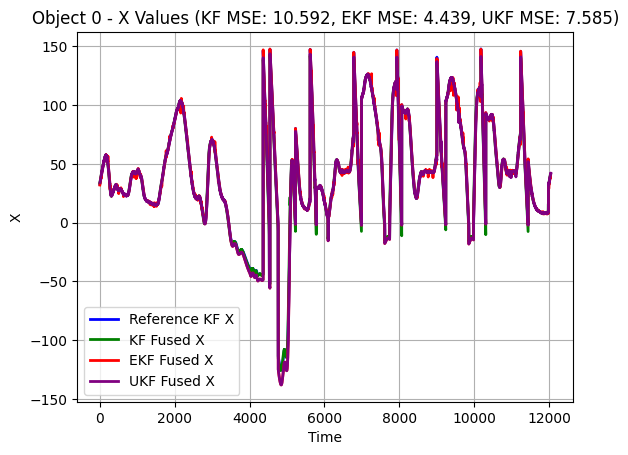

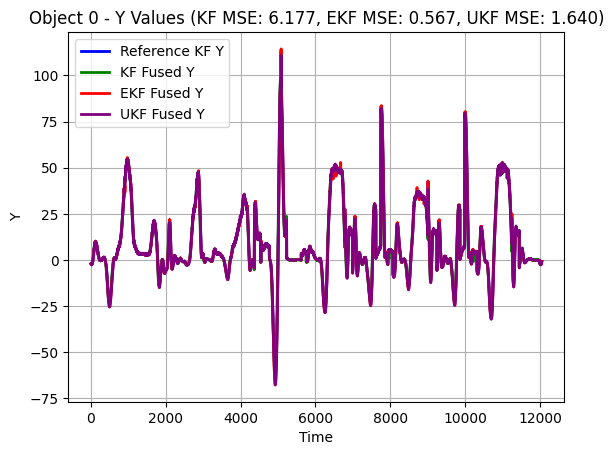

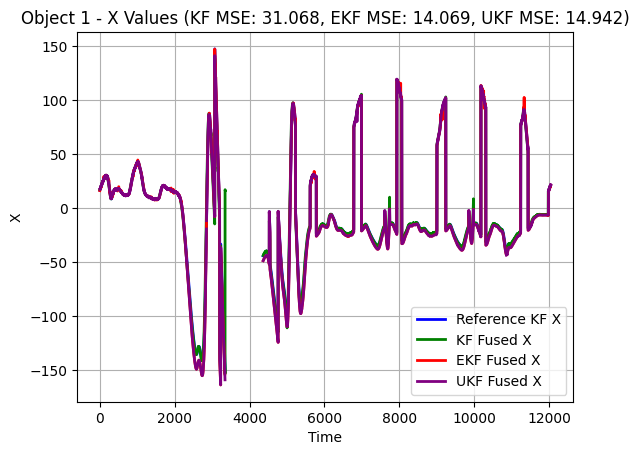

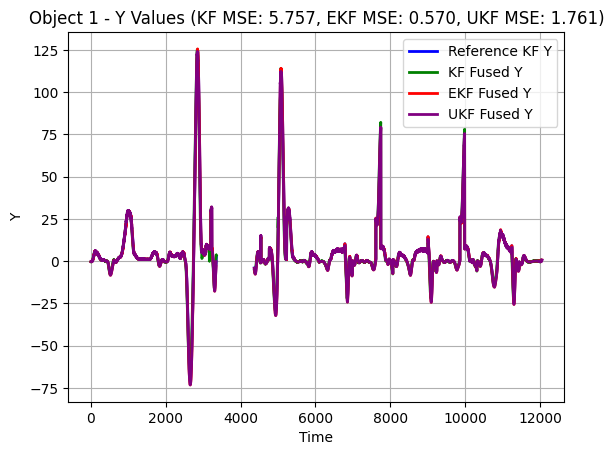

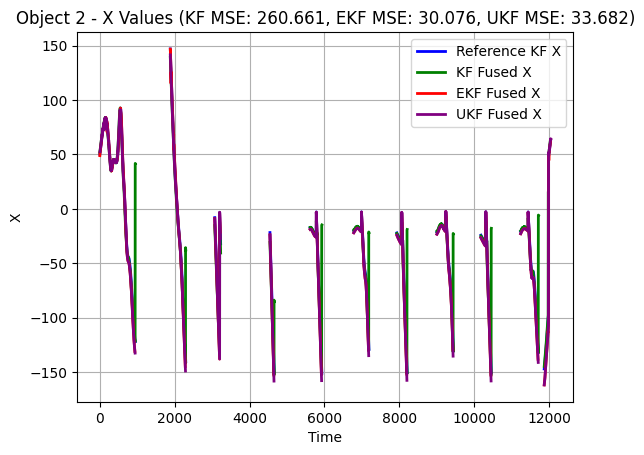

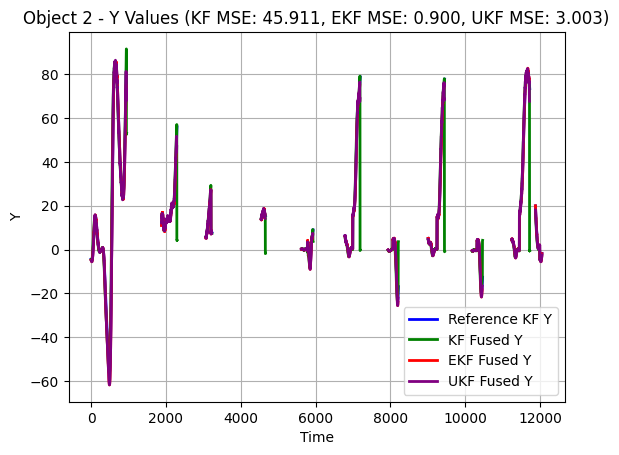

In [4]:
noise = "gaussian"  # change the argument here for the required noise - laplace, cauchy, lognormvariate, gaussian and evaluate the RMSE for different noise and all three filters

# Load all bag files
kf_bag_path = f"Bagfiles_original/Recordings/KF/recording_{noise}_kf.bag"
ekf_bag_path = f"Bagfiles_original/Recordings/EKF/recording_{noise}_ekf.bag"
ukf_bag_path = f"Bagfiles_original/Recordings/UKF/recording_{noise}_ukf.bag"

record_end_time = 11960  # the bag files are 600 seconds long and at 20 Hz frequency

def extract_data_from_bag(bag_path):
    bag = rosbag.Bag(bag_path)

    x_ref = [[] for _ in range(3)]
    y_ref = [[] for _ in range(3)]
    x_fused = [[] for _ in range(5)]  # Adjusted for 5 objects
    y_fused = [[] for _ in range(5)]  # Adjusted for 5 objects

    fused_counter = 0

    for topic, msg, t in bag.read_messages(topics=[
        '/sensors/reference/ikaObjectList', '/sensors/fusion/ikaObjectList']):
        if topic == '/sensors/reference/ikaObjectList':
            for i in range(3):
                if len(msg.objects) > i:
                    x_ref[i].append(msg.objects[i].fMean[0])
                    y_ref[i].append(msg.objects[i].fMean[1])
                else:
                    x_ref[i].append(None)
                    y_ref[i].append(None)
        elif topic == '/sensors/fusion/ikaObjectList':
            fused_counter += 1
            if fused_counter % 2 == 0:
                for i in range(3):  # Modified for 5 objects
                    if len(msg.objects) > i:
                        x_fused[i].append(msg.objects[i].fMean[0])
                        y_fused[i].append(msg.objects[i].fMean[1])
                    else:
                        x_fused[i].append(None)
                        y_fused[i].append(None)

    return x_ref, y_ref, x_fused, y_fused

def compute_closest_fused(x_ref, y_ref, x_fused, y_fused):
    closest_fused_x = [[] for _ in range(3)]
    closest_fused_y = [[] for _ in range(3)]

    for time_idx in range(len(x_ref[0])):
        for ref_idx in range(3):
            if len(x_ref[ref_idx]) > time_idx and len(y_ref[ref_idx]) > time_idx:
                ref_x = x_ref[ref_idx][time_idx]
                ref_y = y_ref[ref_idx][time_idx]
            else:
                ref_x, ref_y = None, None
            if ref_x is None or ref_y is None:
                closest_fused_x[ref_idx].append(None)
                closest_fused_y[ref_idx].append(None)
                continue
            min_dist = float('inf')             
            closest_x = None
            closest_y = None

            for fused_idx in range(3):
                if len(x_fused[fused_idx]) > time_idx and len(y_fused[fused_idx]) > time_idx:
                    fused_x = x_fused[fused_idx][time_idx]
                    fused_y = y_fused[fused_idx][time_idx]
                else:
                    fused_x, fused_y = None, None

                if fused_x is None or fused_y is None:
                    continue

                dist = np.sqrt((fused_x - ref_x) ** 2 + (fused_y - ref_y) ** 2)
                if dist < min_dist:
                    min_dist = dist
                    closest_x = fused_x
                    closest_y = fused_y

            closest_fused_x[ref_idx].append(closest_x)
            closest_fused_y[ref_idx].append(closest_y)

    return closest_fused_x, closest_fused_y


# count None values
def count_none_values(values):
    return sum(1 for v in values if v is None)

# Extract data
x_ref_kf, y_ref_kf, x_fused_kf, y_fused_kf = extract_data_from_bag(kf_bag_path)
closest_fused_x_kf, closest_fused_y_kf = compute_closest_fused(x_ref_kf, y_ref_kf, x_fused_kf, y_fused_kf)

x_ref_ekf, y_ref_ekf, x_fused_ekf, y_fused_ekf = extract_data_from_bag(ekf_bag_path)
closest_fused_x_ekf, closest_fused_y_ekf = compute_closest_fused(x_ref_ekf, y_ref_ekf, x_fused_ekf, y_fused_ekf)

x_ref_ukf, y_ref_ukf, x_fused_ukf, y_fused_ukf = extract_data_from_bag(ukf_bag_path)
closest_fused_x_ukf, closest_fused_y_ukf = compute_closest_fused(x_ref_ukf, y_ref_ukf, x_fused_ukf, y_fused_ukf)

# Count None values filter type
none_count_kf = {
    'x_fused': [count_none_values(closest_fused_x_kf[i]) for i in range(3)],
    'y_fused': [count_none_values(closest_fused_y_kf[i]) for i in range(3)]
}
none_count_ekf = {
    'x_fused': [count_none_values(closest_fused_x_ekf[i]) for i in range(3)],
    'y_fused': [count_none_values(closest_fused_y_ekf[i]) for i in range(3)]
}
none_count_ukf = {
    'x_fused': [count_none_values(closest_fused_x_ukf[i]) for i in range(3)],
    'y_fused': [count_none_values(closest_fused_y_ukf[i]) for i in range(3)]
}

print("KF None counts (X, Y):") # to ensure that we are comparing same number of data points across each filter, 
# not all the objects are present for all 599s of recording and if a filter is unable to detect objects then it will just pass None values 
# and other filters which are tracking this object will keep on accumulating RMSE error thus, out of 12000 timestamps we are just checking 
# that each filter approximately measures the same number of objects at each time stamps
for i in range(3):
    print(f"Object {i + 1}: X - {none_count_kf['x_fused'][i]}, Y - {none_count_kf['y_fused'][i]}")

print("\nEKF None counts (X, Y):")
for i in range(3):
    print(f"Object {i + 1}: X - {none_count_ekf['x_fused'][i]}, Y - {none_count_ekf['y_fused'][i]}")

print("\nUKF None counts (X, Y):")
for i in range(3):
    print(f"Object {i + 1}: X - {none_count_ukf['x_fused'][i]}, Y - {none_count_ukf['y_fused'][i]}")


# filter out None values from two lists
def filter_none_values(ref_values, fused_values):
    ref_filtered = []
    fused_filtered = []
    for ref, fused in zip(ref_values, fused_values):
        if ref is not None and fused is not None:
            ref_filtered.append(ref)
            fused_filtered.append(fused)
    return ref_filtered, fused_filtered

# compute the offset-adjusted fused values
def adjust_fused_with_offset(ref_kf, ref_other, fused_other):
    adjusted_fused = []
    for ref_kf_val, ref_other_val, fused_other_val in zip(ref_kf, ref_other, fused_other):
        if ref_kf_val is not None and ref_other_val is not None and fused_other_val is not None:
            adjusted_fused.append(fused_other_val + (ref_kf_val - ref_other_val))
        else:
            adjusted_fused.append(None)
    return adjusted_fused


# Initialize accumulators for MSE
total_mse_x_kf, total_mse_y_kf = 0, 0
total_mse_x_ekf, total_mse_y_ekf = 0, 0
total_mse_x_ukf, total_mse_y_ukf = 0, 0

all_x_ref_kf, all_x_fused_kf = [], []
all_x_ref_ekf, all_x_fused_ekf = [], []
all_x_ref_ukf, all_x_fused_ukf = [], []

all_y_ref_kf, all_y_fused_kf = [], []
all_y_ref_ekf, all_y_fused_ekf = [], []
all_y_ref_ukf, all_y_fused_ukf = [], []

for i in range(3):
    filtered_x_ref_kf, filtered_x_fused_kf = filter_none_values(x_ref_kf[i], closest_fused_x_kf[i])
    all_x_ref_kf.extend(filtered_x_ref_kf[:record_end_time])
    all_x_fused_kf.extend(filtered_x_fused_kf[:record_end_time])

    filtered_x_ref_ekf, filtered_x_fused_ekf = filter_none_values(x_ref_ekf[i], closest_fused_x_ekf[i])
    all_x_ref_ekf.extend(filtered_x_ref_ekf[:record_end_time])
    all_x_fused_ekf.extend(filtered_x_fused_ekf[:record_end_time])

    filtered_x_ref_ukf, filtered_x_fused_ukf = filter_none_values(x_ref_ukf[i], closest_fused_x_ukf[i])
    all_x_ref_ukf.extend(filtered_x_ref_ukf[:record_end_time])
    all_x_fused_ukf.extend(filtered_x_fused_ukf[:record_end_time])

    # Filter and collect Y values for KF, EKF, and UKF
    filtered_y_ref_kf, filtered_y_fused_kf = filter_none_values(y_ref_kf[i], closest_fused_y_kf[i])
    all_y_ref_kf.extend(filtered_y_ref_kf[:record_end_time])
    all_y_fused_kf.extend(filtered_y_fused_kf[:record_end_time])

    filtered_y_ref_ekf, filtered_y_fused_ekf = filter_none_values(y_ref_ekf[i], closest_fused_y_ekf[i])
    all_y_ref_ekf.extend(filtered_y_ref_ekf[:record_end_time])
    all_y_fused_ekf.extend(filtered_y_fused_ekf[:record_end_time])

    filtered_y_ref_ukf, filtered_y_fused_ukf = filter_none_values(y_ref_ukf[i], closest_fused_y_ukf[i])
    all_y_ref_ukf.extend(filtered_y_ref_ukf[:record_end_time])
    all_y_fused_ukf.extend(filtered_y_fused_ukf[:record_end_time])

# Calculate final MSE for X and Y (KF, EKF, UKF)
mse_x_kf = mean_squared_error(all_x_ref_kf, all_x_fused_kf) if len(all_x_ref_kf) > 0 else float('nan')
mse_y_kf = mean_squared_error(all_y_ref_kf, all_y_fused_kf) if len(all_y_ref_kf) > 0 else float('nan')

mse_x_ekf = mean_squared_error(all_x_ref_ekf, all_x_fused_ekf) if len(all_x_ref_ekf) > 0 else float('nan')
mse_y_ekf = mean_squared_error(all_y_ref_ekf, all_y_fused_ekf) if len(all_y_ref_ekf) > 0 else float('nan')

mse_x_ukf = mean_squared_error(all_x_ref_ukf, all_x_fused_ukf) if len(all_x_ref_ukf) > 0 else float('nan')
mse_y_ukf = mean_squared_error(all_y_ref_ukf, all_y_fused_ukf) if len(all_y_ref_ukf) > 0 else float('nan')

#  Print the final RMSE results
print(f'Final RMSE for X, Y (KF) for {noise} noise: {mse_x_kf:.3f}, {mse_y_kf:.3f}')
print(f'Final RMSE for X, Y (EKF) for {noise} noise: {mse_x_ekf:.3f}, {mse_y_ekf:.3f}')
print(f'Final RMSE for X, Y (UKF) for {noise} noise: {mse_x_ukf:.3f}, {mse_y_ukf:.3f}')

def clamp_values(ref_values, fused_values, percentage=0.1): # clamping only for plotting not taken into acocunt for RMSE calculation..sometines in EKF jacobian collapses and the value shoots 
    # Ensure both ref_values and fused_values are valid and skip None values
    clamped_values = []
    for ref, fused in zip(ref_values, fused_values):
        if ref is None or fused is None:
            clamped_values.append(None)
        else:
            min_limit = ref * (1 - percentage)
            max_limit = ref * (1 + percentage)
            clamped_values.append(np.clip(fused, min_limit, max_limit))
    return clamped_values

for i in range(3):
    # Apply the offset for X fused values (EKF and UKF)
    adjusted_fused_x_ekf = adjust_fused_with_offset(x_ref_kf[i], x_ref_ekf[i], closest_fused_x_ekf[i])
    adjusted_fused_x_ukf = adjust_fused_with_offset(x_ref_kf[i], x_ref_ukf[i], closest_fused_x_ukf[i])

    # Clamp EKF and UKF X values within ±10% of ref KF X values
    adjusted_fused_x_ekf = clamp_values(np.array(x_ref_kf[i]), np.array(adjusted_fused_x_ekf))
    adjusted_fused_x_ukf = clamp_values(np.array(x_ref_kf[i]), np.array(adjusted_fused_x_ukf))

    # Apply the offset for Y fused values (EKF and UKF)
    adjusted_fused_y_ekf = adjust_fused_with_offset(y_ref_kf[i], y_ref_ekf[i], closest_fused_y_ekf[i])
    adjusted_fused_y_ukf = adjust_fused_with_offset(y_ref_kf[i], y_ref_ukf[i], closest_fused_y_ukf[i])

    # Clamp EKF and UKF Y values within ±10% of ref KF Y values
    adjusted_fused_y_ekf = clamp_values(np.array(y_ref_kf[i]), np.array(adjusted_fused_y_ekf))
    adjusted_fused_y_ukf = clamp_values(np.array(y_ref_kf[i]), np.array(adjusted_fused_y_ukf))

    # Filter and calculate MSE for X (KF)
    filtered_x_ref_kf, filtered_x_fused_kf = filter_none_values(x_ref_kf[i], closest_fused_x_kf[i])
    mse_x_kf = mean_squared_error(filtered_x_ref_kf, filtered_x_fused_kf) if len(filtered_x_ref_kf) > 0 else float('nan')
    total_mse_x_kf += mse_x_kf

    # Filter and calculate MSE for X (EKF)
    filtered_x_ref_kf, filtered_x_fused_ekf = filter_none_values(x_ref_kf[i], adjusted_fused_x_ekf)
    mse_x_ekf = mean_squared_error(filtered_x_ref_kf, filtered_x_fused_ekf) if len(filtered_x_ref_kf) > 0 else float('nan')
    total_mse_x_ekf += mse_x_ekf

    # Filter and calculate MSE for X (UKF)
    filtered_x_ref_kf, filtered_x_fused_ukf = filter_none_values(x_ref_kf[i], adjusted_fused_x_ukf)
    mse_x_ukf = mean_squared_error(filtered_x_ref_kf, filtered_x_fused_ukf) if len(filtered_x_ref_kf) > 0 else float('nan')
    total_mse_x_ukf += mse_x_ukf

    # Plot X values for KF, EKF, and UKF
    plt.figure()
    plt.plot(x_ref_kf[i], label='Reference KF X', color='blue', linewidth=2)
    plt.plot(closest_fused_x_kf[i], label='KF Fused X', color='green', linewidth=2)
    plt.plot(adjusted_fused_x_ekf, label='EKF Fused X', color='red', linewidth=2)
    plt.plot(adjusted_fused_x_ukf, label='UKF Fused X', color='purple', linewidth=2)
    plt.title(f'Object {i} - X Values (KF MSE: {mse_x_kf:.3f}, EKF MSE: {mse_x_ekf:.3f}, UKF MSE: {mse_x_ukf:.3f})')
    plt.xlabel('Time')
    plt.ylabel('X')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Repeat for Y
    filtered_y_ref_kf, filtered_y_fused_kf = filter_none_values(y_ref_kf[i], closest_fused_y_kf[i])
    mse_y_kf = mean_squared_error(filtered_y_ref_kf, filtered_y_fused_kf) if len(filtered_y_ref_kf) > 0 else float('nan')
    total_mse_y_kf += mse_y_kf

    filtered_y_ref_kf, filtered_y_fused_ekf = filter_none_values(y_ref_kf[i], adjusted_fused_y_ekf)
    mse_y_ekf = mean_squared_error(filtered_y_ref_kf, filtered_y_fused_ekf) if len(filtered_y_ref_kf) > 0 else float('nan')
    total_mse_y_ekf += mse_y_ekf

    filtered_y_ref_kf, filtered_y_fused_ukf = filter_none_values(y_ref_kf[i], adjusted_fused_y_ukf)
    mse_y_ukf = mean_squared_error(filtered_y_ref_kf, filtered_y_fused_ukf) if len(filtered_y_ref_kf) > 0 else float('nan')
    total_mse_y_ukf += mse_y_ukf

    # Plot Y values for KF, EKF, and UKF
    plt.figure()
    plt.plot(y_ref_kf[i], label='Reference KF Y', color='blue', linewidth=2)
    plt.plot(closest_fused_y_kf[i], label='KF Fused Y', color='green', linewidth=2)
    plt.plot(adjusted_fused_y_ekf, label='EKF Fused Y', color='red', linewidth=2)
    plt.plot(adjusted_fused_y_ukf, label='UKF Fused Y', color='purple', linewidth=2)
    plt.title(f'Object {i} - Y Values (KF MSE: {mse_y_kf:.3f}, EKF MSE: {mse_y_ekf:.3f}, UKF MSE: {mse_y_ukf:.3f})')
    plt.xlabel('Time')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True)
    plt.show()


<img src="images/high_quality_animation.gif" alt="GIF" width="400"/>

This GIF image represents the RMSE values for different filtering techniques after the bag files are recorded against the laplcae noise distribution.

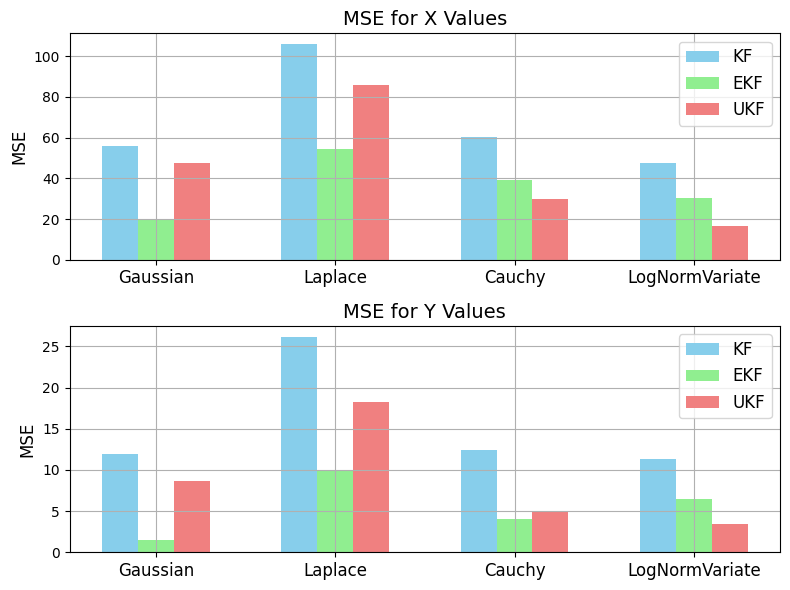

In [5]:
# Data for plotting
filters = ['KF', 'EKF', 'UKF']
noises = ['Gaussian', 'Laplace', 'Cauchy', 'LogNormVariate']
kf_x = [56.027, 105.924, 60.151, 47.577]
kf_y = [11.912, 26.18, 12.475, 11.376]
ekf_x = [19.829, 54.529, 39.144, 30.45]
ekf_y = [1.521, 9.825, 4.046, 6.432]
ukf_x = [47.667, 85.635, 29.684, 16.568]
ukf_y = [8.71, 18.22, 4.856, 3.447]

# Create the figure and axis
fig, axs = plt.subplots(2, 1, figsize=(8,6))

# Bar width
bar_width = 0.2
index = np.arange(len(noises))

# Plot X values
axs[0].bar(index, kf_x, bar_width, label='KF', color='skyblue')
axs[0].bar(index + bar_width, ekf_x, bar_width, label='EKF', color='lightgreen')
axs[0].bar(index + 2 * bar_width, ukf_x, bar_width, label='UKF', color='lightcoral')

axs[0].set_title('MSE for X Values', fontsize=14)
axs[0].set_ylabel('MSE', fontsize=12)
axs[0].set_xticks(index + bar_width)
axs[0].set_xticklabels(noises, fontsize=12)
axs[0].legend(fontsize=12)
axs[0].grid(True)

# Plot Y values
axs[1].bar(index, kf_y, bar_width, label='KF', color='skyblue')
axs[1].bar(index + bar_width, ekf_y, bar_width, label='EKF', color='lightgreen')
axs[1].bar(index + 2 * bar_width, ukf_y, bar_width, label='UKF', color='lightcoral')

axs[1].set_title('MSE for Y Values', fontsize=14)
axs[1].set_ylabel('MSE', fontsize=12)
axs[1].set_xticks(index + bar_width)
axs[1].set_xticklabels(noises, fontsize=12)
axs[1].legend(fontsize=12)
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [6]:
# Function to process rosbag and extract data including yaw rate based RMSE calculation for straight ahead motion and turning scenario
def extract_data_from_bag_with_yaw(bag_path):
    bag = rosbag.Bag(bag_path)

    x_ref = [[] for _ in range(3)]
    y_ref = [[] for _ in range(3)]
    yaw_ref = [[] for _ in range(3)]  # To store yaw rate reference
    x_fused = [[] for _ in range(5)]  # Adjusted to consider up to 5 objects
    y_fused = [[] for _ in range(5)]  # Adjusted to consider up to 5 objects
    yaw_fused = [[] for _ in range(5)]  # Store yaw rate for fused objects

    fused_counter = 0

    # Read data from the rosbag
    for topic, msg, t in bag.read_messages(topics=['/sensors/reference/ikaObjectList', '/sensors/fusion/ikaObjectList']):
        if topic == '/sensors/reference/ikaObjectList':
            for i in range(3):
                if len(msg.objects) > i:
                    x_ref[i].append(msg.objects[i].fMean[0])
                    y_ref[i].append(msg.objects[i].fMean[1])
                    yaw_ref[i].append(msg.objects[i].fMean[6])  # Yaw rate reference
                else:
                    x_ref[i].append(None)
                    y_ref[i].append(None)
                    yaw_ref[i].append(None)
        elif topic == '/sensors/fusion/ikaObjectList':
            fused_counter += 1
            if fused_counter % 2 == 0:
                for i in range(3):  # Modified to include up to 5 objects
                    if len(msg.objects) > i:
                        x_fused[i].append(msg.objects[i].fMean[0])
                        y_fused[i].append(msg.objects[i].fMean[1])
                        yaw_fused[i].append(msg.objects[i].fMean[6])  # Yaw rate fused
                    else:
                        x_fused[i].append(None)
                        y_fused[i].append(None)
                        yaw_fused[i].append(None)

    return x_ref, y_ref, yaw_ref, x_fused, y_fused, yaw_fused

# Modify the computation of closest fused objects to include yaw rate check
def compute_closest_fused_with_yaw(x_ref, y_ref, yaw_ref, x_fused, y_fused, yaw_fused):
    closest_fused_x = [[] for _ in range(3)]
    closest_fused_y = [[] for _ in range(3)]
    closest_fused_yaw = [[] for _ in range(3)]  # Store closest yaw rate

    for time_idx in range(len(x_ref[0])):
        for ref_idx in range(3):
            if len(x_ref[ref_idx]) > time_idx and len(y_ref[ref_idx]) > time_idx:
                ref_x = x_ref[ref_idx][time_idx]
                ref_y = y_ref[ref_idx][time_idx]
                ref_yaw = yaw_ref[ref_idx][time_idx]
            else:
                ref_x, ref_y, ref_yaw = None, None, None

            if ref_x is None or ref_y is None or ref_yaw is None:
                closest_fused_x[ref_idx].append(None)
                closest_fused_y[ref_idx].append(None)
                closest_fused_yaw[ref_idx].append(None)
                continue

            min_dist = float('inf')             
            closest_x = None
            closest_y = None
            closest_yaw = None

            # Consider all available fused objects (up to 5 objects)
            for fused_idx in range(3):
                if len(x_fused[fused_idx]) > time_idx and len(y_fused[fused_idx]) > time_idx:
                    fused_x = x_fused[fused_idx][time_idx]
                    fused_y = y_fused[fused_idx][time_idx]
                    fused_yaw = yaw_fused[fused_idx][time_idx]
                else:
                    fused_x, fused_y, fused_yaw = None, None, None

                if fused_x is None or fused_y is None or fused_yaw is None:
                    continue

                dist = np.sqrt((fused_x - ref_x) ** 2 + (fused_y - ref_y) ** 2)
                if dist < min_dist:
                    min_dist = dist
                    closest_x = fused_x
                    closest_y = fused_y
                    closest_yaw = fused_yaw

            closest_fused_x[ref_idx].append(closest_x)
            closest_fused_y[ref_idx].append(closest_y)
            closest_fused_yaw[ref_idx].append(closest_yaw)

    return closest_fused_x, closest_fused_y, closest_fused_yaw

# Function to compute RMSE based on yaw rate condition here in acdc bag files i have divided into yawarate > 0.3 as turn and yawrate < 0.3 as straight ahead motion
def compute_yaw_rate_rmse(x_ref, y_ref, yaw_ref, x_fused, y_fused, condition):
    filtered_x_ref = []
    filtered_y_ref = []
    filtered_x_fused = []
    filtered_y_fused = []

    for i in range(3):
        for ref_x, ref_y, ref_yaw, fused_x, fused_y in zip(x_ref[i], y_ref[i], yaw_ref[i], x_fused[i], y_fused[i]):
            if ref_yaw is not None and ((condition == "greater" and abs(ref_yaw) > 0.3) or (condition == "less" and abs(ref_yaw) <= 0.3)):
                if ref_x is not None and ref_y is not None and fused_x is not None and fused_y is not None:
                    filtered_x_ref.append(ref_x)
                    filtered_y_ref.append(ref_y)
                    filtered_x_fused.append(fused_x)
                    filtered_y_fused.append(fused_y)

    mse_x = mean_squared_error(filtered_x_ref, filtered_x_fused) if len(filtered_x_ref) > 0 else float('nan')
    mse_y = mean_squared_error(filtered_y_ref, filtered_y_fused) if len(filtered_y_ref) > 0 else float('nan')

    rmse_x = np.sqrt(mse_x) if len(filtered_x_ref) > 0 else float('nan')
    rmse_y = np.sqrt(mse_y) if len(filtered_y_ref) > 0 else float('nan')

    return rmse_x, rmse_y

# Extract data for KF, EKF, and UKF including yaw rate
x_ref_kf, y_ref_kf, yaw_ref_kf, x_fused_kf, y_fused_kf, yaw_fused_kf = extract_data_from_bag_with_yaw(kf_bag_path)
x_ref_ekf, y_ref_ekf, yaw_ref_ekf, x_fused_ekf, y_fused_ekf, yaw_fused_ekf = extract_data_from_bag_with_yaw(ekf_bag_path)
x_ref_ukf, y_ref_ukf, yaw_ref_ukf, x_fused_ukf, y_fused_ukf, yaw_fused_ukf = extract_data_from_bag_with_yaw(ukf_bag_path)

# Compute closest fused values including yaw rate
closest_fused_x_kf, closest_fused_y_kf, closest_fused_yaw_kf = compute_closest_fused_with_yaw(x_ref_kf, y_ref_kf, yaw_ref_kf, x_fused_kf, y_fused_kf, yaw_fused_kf)
closest_fused_x_ekf, closest_fused_y_ekf, closest_fused_yaw_ekf = compute_closest_fused_with_yaw(x_ref_ekf, y_ref_ekf, yaw_ref_ekf, x_fused_ekf, y_fused_ekf, yaw_fused_ekf)
closest_fused_x_ukf, closest_fused_y_ukf, closest_fused_yaw_ukf = compute_closest_fused_with_yaw(x_ref_ukf, y_ref_ukf, yaw_ref_ukf, x_fused_ukf, y_fused_ukf, yaw_fused_ukf)

# Compute RMSE for yaw rate > 0.2 and yaw rate <= 0.2 for KF, EKF, and UKF
rmse_greater_x_kf, rmse_greater_y_kf = compute_yaw_rate_rmse(x_ref_kf, y_ref_kf, yaw_ref_kf, closest_fused_x_kf, closest_fused_y_kf, "greater")
rmse_less_x_kf, rmse_less_y_kf = compute_yaw_rate_rmse(x_ref_kf, y_ref_kf, yaw_ref_kf, closest_fused_x_kf, closest_fused_y_kf, "less")

rmse_greater_x_ekf, rmse_greater_y_ekf = compute_yaw_rate_rmse(x_ref_ekf, y_ref_ekf, yaw_ref_ekf, closest_fused_x_ekf, closest_fused_y_ekf, "greater")
rmse_less_x_ekf, rmse_less_y_ekf = compute_yaw_rate_rmse(x_ref_ekf, y_ref_ekf, yaw_ref_ekf, closest_fused_x_ekf, closest_fused_y_ekf, "less")

rmse_greater_x_ukf, rmse_greater_y_ukf = compute_yaw_rate_rmse(x_ref_ukf, y_ref_ukf, yaw_ref_ukf, closest_fused_x_ukf, closest_fused_y_ukf, "greater")
rmse_less_x_ukf, rmse_less_y_ukf = compute_yaw_rate_rmse(x_ref_ukf, y_ref_ukf, yaw_ref_ukf, closest_fused_x_ukf, closest_fused_y_ukf, "less")

# Function to compute root-square of RMSE in X and Y
def root_square_rmse(rmse_x, rmse_y):
    return np.sqrt(rmse_x**2 + rmse_y**2)

# Compute root-square RMSE for all conditions
rs_rmse_greater_kf = root_square_rmse(rmse_greater_x_kf, rmse_greater_y_kf)
rs_rmse_less_kf = root_square_rmse(rmse_less_x_kf, rmse_less_y_kf)

rs_rmse_greater_ekf = root_square_rmse(rmse_greater_x_ekf, rmse_greater_y_ekf)
rs_rmse_less_ekf = root_square_rmse(rmse_less_x_ekf, rmse_less_y_ekf)

rs_rmse_greater_ukf = root_square_rmse(rmse_greater_x_ukf, rmse_greater_y_ukf)
rs_rmse_less_ukf = root_square_rmse(rmse_less_x_ukf, rmse_less_y_ukf)

# Print the results
print("KF - Root-Square RMSE when yaw rate > 0.2:", rs_rmse_greater_kf)
print("KF - Root-Square RMSE when yaw rate <= 0.2:", rs_rmse_less_kf)

print("EKF - Root-Square RMSE when yaw rate > 0.2:", rs_rmse_greater_ekf)
print("EKF - Root-Square RMSE when yaw rate <= 0.2:", rs_rmse_less_ekf)

print("UKF - Root-Square RMSE when yaw rate > 0.2:", rs_rmse_greater_ukf)
print("UKF - Root-Square RMSE when yaw rate <= 0.2:", rs_rmse_less_ukf)

KF - Root-Square RMSE when yaw rate > 0.2: 9.565615103219933
KF - Root-Square RMSE when yaw rate <= 0.2: 7.189520105950034
EKF - Root-Square RMSE when yaw rate > 0.2: 5.590783334985858
EKF - Root-Square RMSE when yaw rate <= 0.2: 4.472448084283519
UKF - Root-Square RMSE when yaw rate > 0.2: 7.984276811486487
UKF - Root-Square RMSE when yaw rate <= 0.2: 7.439860009002116


<img src="images/excel_mse.png" alt="GIF" width="400"/>

| **Filter**    | **KF (CA)** |            | **EKF (CTRA)** |            | **UKF (CTRA)** |            | **KF (CA)** |                        | **EKF (CTRA)** |                        | **UKF (CTRA)** |                        |
|---------------|-------------|------------|----------------|------------|----------------|------------|-------------|------------------------|----------------|------------------------|----------------|------------------------|
| **Noise**     | **X**       | **Y**      | **X**          | **Y**      | **X**          | **Y**      | **dΨ/dt > 0.3 (rad s-1)** | **dΨ/dt < 0.3** | **dΨ/dt > 0.3** | **dΨ/dt < 0.3** | **dΨ/dt > 0.3** | **dΨ/dt < 0.3** |
| **Gaussian**  | 56.03       | 11.91      | 19.83          | 1.52       | 47.67          | 8.71       | 9.56        | 7.18                  | 5.59           | 4.46                  | 7.98           | 7.40                  |
| **Laplace**   | 105.92      | 26.18      | 54.53          | 9.83       | 85.64          | 18.22      | 12.78       | 10.51                 | 6.71           | 8.17                  | 10.90          | 10.09                 |
| **Cauchy**    | 60.15       | 12.48      | 39.14          | 4.05       | 29.68          | 4.86       | 9.12        | 7.23                  | 6.19           | 6.61                  | 6.14           | 5.84                  |
| **LogNormVariate** | 47.58   | 11.38      | 30.45          | 6.43       | 16.57          | 3.45       | 9.03        | 6.59                  | 5.43           | 6.13                  | 4.26           | 4.50                  |
| **Average**   | 67.42       | 15.49      | 35.99          | 5.46       | 44.89          | 8.81       | 9.30        | 6.89                  | 5.51           | 5.30                  | 6.12           | 5.95                  |
| **% Improvement** | -        | -          | 46.62          | 64.77      | 33.42          | 43.12      | -           | -                     | 40.72          | 23.09                 | 34.16          | 13.58                 |


### 1. *Approximation of Nonlinearities*:
   - *EKF*: The EKF linearizes the system around the current estimate using a first-order Taylor expansion (Jacobian matrix). This works well if the system's nonlinearities are mild and the linearization is accurate. When the system is smooth, and the dynamics do not change significantly, the EKF can give accurate results.
     - *When EKF is better*: If the nonlinearities in the system are moderate and can be well-approximated by a first-order expansion, EKF will likely outperform UKF because of its lower computational complexity.
     - *For example*: In Gaussian noise environments (as in our results), EKF may perform better due to the mild nonlinearity and the fact that the system dynamics are close to linear around the operating point. This is why EKF has the lowest MSE under Gaussian noise.

   - *UKF: The UKF, on the other hand, does not rely on linearization. Instead, it uses a deterministic sampling technique called the **unscented transform*, which selects sigma points to capture the mean and covariance more accurately in highly nonlinear systems.
     - *When UKF is better*: UKF tends to perform better in scenarios with significant nonlinearities, where the first-order linearization of EKF is insufficient. If the dynamics are more complex or the noise is non-Gaussian (such as with Laplace or Cauchy distributions), UKF can give a more accurate estimate of the state by better capturing the higher-order moments of the distribution.
     - *For example*: In our results, UKF outperforms EKF in the presence of Cauchy and Log-Normal noise because these types of noise introduce heavy tails and greater nonlinearity, where the UKF’s unscented transform provides a better estimate.

### 2. *Assumption About Noise*:
   - *EKF*: EKF assumes Gaussian noise, which works well when the noise is actually Gaussian. However, when the noise distribution deviates significantly from Gaussian (e.g., heavy-tailed distributions like Cauchy or Laplace), EKF struggles because its linearization does not account for these more extreme cases.
     - In our table, EKF performs relatively poorly in Laplace and Cauchy noise environments because these distributions have sharper peaks and heavier tails than Gaussian noise, making the EKF’s linear approximation less effective.

   - *UKF*: Since UKF works directly with the distribution of sigma points and captures the uncertainty more accurately, it is generally more robust to different types of noise, including non-Gaussian noise. It doesn’t make a strict Gaussian assumption in its internal calculations.
     - This explains why UKF performs better than EKF in Cauchy and Log-Normal noise environments—these environments involve higher-order statistical moments that UKF captures better than EKF.

### 3. *Computational Complexity*:
   - *EKF*: EKF is computationally simpler because it only requires the computation of the Jacobian matrix, making it less demanding for real-time applications. This simplicity comes at the cost of accuracy when nonlinearities are significant or when the noise is not Gaussian.
   
   - *UKF*: UKF is more computationally intensive because it generates multiple sigma points, but it compensates by better handling the system's nonlinearities. This is why, under certain conditions, UKF can outperform EKF despite its higher computational cost.

### 4. *Impact of System Dynamics*:
   - *EKF*: In cases where the system's dynamics are well-understood and not highly nonlinear (e.g., a vehicle moving in a straight line or predictable motion), EKF can be sufficient and perform well.
   - *UKF*: When system dynamics are more unpredictable or inherently nonlinear (e.g., rapidly changing trajectories or complex sensor readings), UKF will generally have an advantage because it models the distribution of the state better.

### 5. *Filter Tuning*:
   - Both EKF and UKF require tuning of process and measurement noise covariance matrices. In some cases, a well-tuned EKF can perform better than a poorly tuned UKF, or vice versa. The performance differences in specific scenarios could be related to how well each filter is tuned for that specific environment. In our case the UKF needs to be tuned for other noises like Laplace and Cauchy to outperform EKF. Currently, we tuned the UKF for LogNormvariate noise as we heavily shifted it's mean in both x and y positions of sensors around 1 m - 1.25 m. 

### Evaluation:


### Conclusion
- *KF* :
  - KF (CV), in straight ahead motion (low yaw rate < 0.3 rad s_1) KF still performs fine.
  - However, it performs poorly when non-Gaussian noise distributions such as Laplace, Cauchy, or LogNormalVariate are introduced. The assumption of linearity limits its ability to handle complex  noise patterns
- *EKF* :
  - EKF (CTRA), is robust for nonlinear models, assumes a Gaussian noise distribution and performs the best for Gaussian noise distribution.
  - Linearization errors can accumulate in highly nonlinear systems (high yaw rates), struggles under more extreme non-Gaussian conditions like Cauchy noise compared to UKF.
  
- *UKF* :
  - UKF (CTRA), while better at handling nonlinearities and non-Gaussian noise (particularly heavy-tailed distributions like Cauchy and skewed ones like LogNormalVariate).
  - Computational complexity may also arise with UKF due to its more intricate design compared to EKF and shows weaker performance in Y compared to EKF, suggesting it requires parameters tuning to extract the best performance for different noises.

In our case, the Gaussian noise scenario shows EKF performing better because the system likely fits the linear approximation assumption better. Conversely, under Cauchy and Log-Normal noise, UKF outperforms EKF due to its better handling of non-Gaussian distributions and higher-order nonlinearity.

This report presents the implementation and evaluation of the Kalman Filter (KF), Extended Kalman Filter (EKF), and Unscented Kalman Filter (UKF) for tracking under gaussian and non-Gaussian noise conditions and assuming linear and non-linear motion models. These findings highlight the importance of selecting appropriate filtering techniques based on the nature of the noise and system dynamics, and they provide valuable insights for improving the reliability of sensor fusion in real-world applications.


#### References

*The list of references lists further information about all work that has been cited. Please make sure to hyperlink all references.*

| # | Year | Authors | Title |
| --- | --- | --- | --- |
| 1 | 2023-24 | ACDC Course, ika RWTH Aachen University | [Automated and Connected Driving Challenges (ACDC)](https://github.com/ika-rwth-aachen/acdc)|
| 2 | 2004 | Maria Isabel Ribeiro | [Kalman and Extended Kalman Filters: Concept, Derivation and Properties](http://users.isr.ist.utl.pt/~mir/pub/kalman.pdf) |
| 3 | 2021 | Ze Liu, Yingfeng Cai, Hai Wang & Long Chen  | [Surrounding Objects Detection and Tracking for Autonomous Driving Using LiDAR and Radar Fusion](https://cjme.springeropen.com/articles/10.1186/s10033-021-00630-y) |
| 4 | 2007 | Robin Schubert, Eric Richter & Gerd Wanielik | [Comparison and evaluation of advanced motion models for vehicle tracking](https://www.researchgate.net/publication/4370048_Comparison_and_evaluation_of_advanced_motion_models_for_vehicle_trackin) |
| 5 | 2024 | Aleksa, M., Schaub, A., Erdelean, I. | [Impact analysis of Advanced Driver Assistance Systems (ADAS) regarding road safety – computing reduction potentials](https://etrr.springeropen.com/articles/10.1186/s12544-024-00654-0#citeas) |
| 6 | 2023 | Numan Senel, Klaus Kefferpütz, Kristina Doycheva & Gordon Elger | [Multi-Sensor Data Fusion for Real-Time Multi-Object Tracking](https://www.mdpi.com/2227-9717/11/2/501)|
| 7 | 2007 | Stanislaw Konatowski & A. T. Pieniężny | [A comparison of estimation accuracy by the use of KF, EKF & UKF filters](https://www.researchgate.net/publication/269030334_A_comparison_of_estimation_accuracy_by_the_use_of_KF_EKF_UKF_filters) |
| 8 | 2014 | Marcin Malinowski, Janusz Kwiecień | [Study of the Effectiveness of Different Kalman Filtering Methods and Smoothners in Object Tracking based on Simulation Test](https://intapi.sciendo.com/pdf/10.2478/rgg-2014-0008) |
| 10 | 2000 | Eric A. Wan and Rudolph Wan der Merwe| [The Unscented Kalman Filter for Nonlinear Estimation](https://groups.seas.harvard.edu/courses/cs281/papers/unscented.pdf) |
